# 02 Residual Stream / Logit Lens / Activation Patching

## このノートブックの目的

[Qwen3-4B](#ref-qwen-2025) は Alibaba が公開している Transformer 構造の大規模言語モデル (LLM) で、約 40 億パラメータを持ち、与えられた token 列から次に来る token の確率分布を予測する。本ノートでは、その内部計算を 3 つの視点から観察する。

| 概念 | 概要 |
|------|------|
| **Residual Stream** | 各 Transformer layer の入出力となる hidden state のベクトル系列 |
| **Logit Lens** | 各 layer 後の hidden state を lm_head に通して「その時点でのモデルの予測」を読む |
| **Activation Patching** | clean run の hidden state を corrupt run に注入し、各 layer の因果的寄与を測る |

### 実験設定

| | プロンプト | 期待する次トークン |
|---|---|---|
| **clean** | `"The capital of Japan is"` | ` Tokyo` |
| **corrupt** | `"The capital of France is"` | ` Paris` |

clean run の hidden state を layer k で corrupt run に注入したとき、出力がどう変化するかを計測する。


## 0. 環境セットアップ（3環境 自動切替: Colabだけ pip / path も自動）


In [1]:
# 3環境(Mac/Win/Colab)を同一ファイルで動かすための判定。Colabのみ pip（Mac/Winはenvに在るのでskip）。
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "transformers==5.9.0" "accelerate==1.13.0"
    print("Colab: pip done")
else:
    print("local(Mac/Win): pip skip（env利用）")

local(Mac/Win): pip skip（env利用）


## このノートブックの構成

ノート全体は 5 つのパートに分かれています。

### Part 1. 準備（Section 1–4）

モデルとトークナイザーを読み込み、入力プロンプトの token 表と最終出力（next-token 確率）を確認します。

- **1.** 環境セットアップ
- **2.** モデルとトークナイザーの読み込み
- **3.** トークンテーブル
- **4.** モデルの最終出力：next-token distribution

### Part 2. 入口・出口・単語埋め込みと residual stream（Section 5–7）

embedding / unembedding / softmax の対応関係、語彙埋め込みの意味空間（前回の GloVe との接続）、そして
各 layer の出力である hidden state（residual stream）の構造を確認します。以降の Logit Lens / Activation Patching の前提です。

- **5.** 入口と出口：embedding / unembedding / softmax
  - 入口：token ID → embedding / 出口：hidden state → logits / softmax / embedding と unembedding の重み共有
- **6.** 単語埋め込みを覗く：語彙埋め込みの意味空間
  - tied な $W_E$ を単語ベクトルとして PCA / t-SNE で可視化（似た意味が集まる）
  - 少数語版（6 カテゴリ）と多語版（10 カテゴリ・約 120 語）
  - 言語をまたぐ：英語↔中国語の対訳ペアの位置関係（概念中心の並び）
  - 多言語（7 言語）に拡張：英語ハブの star（t-SNE）
- **7.** residual stream と hidden_states の対応
  - logit lens の読み出し関数 / k=K は最終出力と一致する（sanity check）

### Part 3. Logit Lens（Section 8–9）

各 layer の hidden state を `lm_head` に通して「その時点でのモデルの予測」として読む可視化を、clean / corrupt の 2 通りで眺めます。

- **8.** Logit Lens — clean run
  - 最後の position の logit lens / 全 position の logit lens（top-1 token と target rank）
- **9.** Logit Lens 比較 — clean vs corrupt
  - 最後の position：clean vs corrupt / 全 position：corrupt prompt / logit-difference metric で見る logit lens

### Part 4. Attention の内部（Section 10）

各 Transformer block の attention が、token 同士をどう参照し合うかを self-attention matrix として観察します。個別 head の役割から、全 head の俯瞰、層ごとの個性度までを見ます。次パートの Activation Patching への橋渡しになります。

- **10.** Attention の内部：self-attention matrix を覗く
  - 役割の違う個別 head（previous-token / attention sink / content link）
  - 全 head を一望する差分モザイク（per-layer sort）
  - 層ごとの attention 個性度と L24 の帯

### Part 5. Activation Patching（Section 11–15）

clean run の hidden state を corrupt run に注入し、最終出力がどれだけ clean 側に戻るか（recovery）を、layer と position の両軸で測ります。

- **11.** Activation Patching の概念と実装
  - 概念 / コード（`run_patch(k)`）/ 数式での定式化 / hidden_states と patch site の対応 / 概念図
- **12.** 補足：forward hook の仕組みと挿入場所
  - PyTorch の forward hook / target_module 3 種類 / `Qwen3Model.forward` のソースで hook 位置を確認 / 各 target_module の forward 戻り値の形を確認
- **13.** 全 layer スイープ
  - パッチ注入後の P(answer) / Recovery curve / Logit Lens と Activation Patching の比較
- **14.** 特定 layer のパッチ後 top-k 比較
- **15.** Activation Patching Grid：layer × position
  - `run_patch_at_position` の定義 / 全組合せで patching を実行 / heatmap として描画 / 観察と解釈

### まとめ・参考文献（Section 16）

- **16.** まとめ
  - 観察結果 / 解釈 / 参考文献・参考資料


## 1. 環境セットアップ

In [2]:
%matplotlib inline
import json
from pathlib import Path
import torch
import inspect
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MODEL_ID = "Qwen/Qwen3-4B"

# Jupyter はこのノートのあるフォルダから起動してください
outputs_dir = (Path("outputs") if IN_COLAB else Path("../outputs"))
outputs_dir.mkdir(parents=True, exist_ok=True)
print(f"model_id : {MODEL_ID}")
print(f"outputs  : {outputs_dir.name}/")

# デバイス選択
if torch.cuda.is_available():
    device = "cuda"
    torch_dtype = torch.bfloat16
elif torch.backends.mps.is_available():
    device = "mps"
    torch_dtype = torch.float16
else:
    device = "cpu"
    torch_dtype = torch.float32
print(f"device   : {device}")
print(f"dtype    : {torch_dtype}")


model_id : Qwen/Qwen3-4B
outputs  : outputs/
device   : mps
dtype    : torch.float16


In [3]:
# 多言語フォント設定（3環境 Mac/Win/Colab）: CJK(日中韓ハングル) + アラビア語。
# matplotlib の既定 DejaVu Sans はこれらの glyph を持たないので、font.family にリストを指定し
# 「字ごとに先頭から fallback」させる（matplotlib >= 3.6）。§6 以降の多言語ラベルで必要。
import sys as _sysf
import matplotlib.font_manager as _fm

# Colab(Linux) は CJK/ハングル/アラビア語フォントを apt で導入して登録
if "google.colab" in _sysf.modules:
    import subprocess as _spc, glob as _gc
    _spc.run(["apt-get", "-qq", "-y", "install",
              "fonts-ipafont-gothic", "fonts-wqy-zenhei", "fonts-nanum", "fonts-noto-core"], check=False)
    _spc.run([_sysf.executable, "-m", "pip", "install", "-q", "arabic-reshaper", "python-bidi"], check=False)
    for _pat in ("/usr/share/fonts/**/ipag*.ttf",
                 "/usr/share/fonts/**/wqy-zenhei*.tt?",
                 "/usr/share/fonts/**/NanumGothic*.ttf",
                 "/usr/share/fonts/**/NotoSansArabic*.ttf",
                 "/usr/share/fonts/**/NotoNaskhArabic*.ttf",
                 "/usr/share/fonts/**/NotoSans-*.ttf"):
        for _fp in _gc.glob(_pat, recursive=True):
            try:
                _fm.fontManager.addfont(_fp)
            except Exception:
                pass

_available = {f.name for f in _fm.fontManager.ttflist}
_font_candidates = [
    # 日本語
    "Hiragino Sans", "Yu Gothic", "Meiryo", "IPAGothic", "Noto Sans CJK JP", "Noto Sans JP",
    # 中国語(簡体)  Mac=PingFang / Win=Microsoft YaHei / Colab=WenQuanYi
    "PingFang SC", "Microsoft YaHei", "WenQuanYi Zen Hei", "Noto Sans CJK SC",
    # 韓国語(ハングル)  Mac=Apple SD Gothic Neo / Win=Malgun Gothic / Colab=Nanum
    "Apple SD Gothic Neo", "AppleGothic", "Malgun Gothic", "NanumGothic", "Nanum Gothic",
    "Noto Sans CJK KR", "Noto Sans KR",
    # アラビア語(字形はフォント、RTL 並べ替えは _fix_rtl)  Mac=Geeza Pro / Win=Segoe UI / Colab=Noto
    "Geeza Pro", "Segoe UI", "Noto Sans Arabic", "Noto Naskh Arabic",
    # 全部入り(Mac)
    "Arial Unicode MS",
]
_fonts = [n for n in _font_candidates if n in _available]
plt.rcParams["font.family"] = _fonts + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("font.family =", plt.rcParams["font.family"])

# RTL(アラビア語/ヘブライ語) 整形。libraqm 付き matplotlib(Mac の pip wheel 等)は native 整形するので raw で正しい。
# libraqm 非搭載(古い/一部 Linux・Colab)だけ arabic-reshaper + python-bidi で手動整形する。版番号でなくバイナリで決まる。
RESHAPE_RTL = "auto"   # "auto"=libraqm有無で自動 / True=必ず手動 / False=整形しない
try:
    import matplotlib.ft2font as _ft2
    _MPL_HAS_RAQM = bool(getattr(_ft2, "__libraqm_version__", ""))
except Exception:
    _MPL_HAS_RAQM = False
def _need_manual_reshape():
    return (not _MPL_HAS_RAQM) if RESHAPE_RTL == "auto" else bool(RESHAPE_RTL)
try:
    import arabic_reshaper as _arsh
    from bidi.algorithm import get_display as _bidi_disp
    import re as _re_rtl
    _RTL_RE = _re_rtl.compile(r'[֐-ࣿﭐ-﷿ﹰ-﻿]')
    def _fix_rtl(_s):
        if _need_manual_reshape() and _s and _RTL_RE.search(_s):
            return _bidi_disp(_arsh.reshape(_s))
        return _s
except Exception:
    def _fix_rtl(_s):
        return _s
print(f"[RTL] libraqm={_MPL_HAS_RAQM} RESHAPE_RTL={RESHAPE_RTL} -> 手動整形={_need_manual_reshape()}")


font.family = ['Hiragino Sans', 'PingFang SC', 'Apple SD Gothic Neo', 'AppleGothic', 'NanumGothic', 'Nanum Gothic', 'Geeza Pro', 'Arial Unicode MS', 'DejaVu Sans']
[RTL] libraqm=True RESHAPE_RTL=auto -> 手動整形=False


## 2. モデルとトークナイザーの読み込み

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM, PreTrainedModel

# トークナイザー の読み込み
print("Loading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"  vocab_size = {tokenizer.vocab_size}")

# Transformer モデルの読み込み
print("Loading model ...")
model: PreTrainedModel = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,
    attn_implementation="eager",
)
model.to(device)  # GPU/MPS/CPU に転送  # pyright: ignore[reportArgumentType]
model.eval() # 推論専用の動作に設定（Dropout オフなど）
torch.set_grad_enabled(False)  # 計算グラフ構築オフ
print(f"  device     : {next(model.parameters()).device}")
print(f"  dtype      : {next(model.parameters()).dtype}")

K: int = model.config.num_hidden_layers
hidden_size: int = model.config.hidden_size
print(f"  layers K   : {K}")
print(f"  hidden_size: {hidden_size}")


Loading tokenizer ...


  vocab_size = 151643
Loading model ...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  device     : mps:0
  dtype      : torch.float16
  layers K   : 36
  hidden_size: 2560


### ヘルパー関数 (tokenizer使用)

In [5]:
# トークンテーブルを表示
def show_token_table(text: str) -> pd.DataFrame:
    """テキストをトークナイズして位置・ID・piece の表を返す。"""

    # add_special_tokens=False: BOS などを付加せず、テキスト本体だけをトークン化
    ids = tokenizer.encode(text, add_special_tokens=False)

    rows = []
    for pos, tid in enumerate(ids):
        # convert_ids_to_tokens: トークナイザー内部の raw 表現（Ġ 付きなど）
        piece = tokenizer.convert_ids_to_tokens(tid)
        # decode: token ID を人間が読めるテキストに変換
        decoded = tokenizer.decode([tid])
        rows.append({
            "pos":      pos,
            "token_id": tid,
            "piece":    piece,   
            "decoded":  repr(decoded), # 'capital' のように表示
        })
    return pd.DataFrame(rows).set_index("pos")

# 確率上位 k トークンの表を返す
def topk_table(logits: torch.Tensor, k: int = 10) -> pd.DataFrame:
    """logits [vocab] から確率上位 k トークンの DataFrame を返す。"""

    # logits をソフトマックスで確率に変換（float32 で計算して精度を確保）
    probs = torch.softmax(logits.float(), dim=-1)

    # 確率上位 k 個の値とインデックスを取得
    top_vals, top_ids = torch.topk(probs, k)

    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_vals.tolist()), start=1):
        decoded = tokenizer.decode([tid])   # token ID → テキスト
        rows.append({
            "rank":     rank,
            "token_id": tid,
            "decoded":  repr(decoded),    # 先頭スペースなどを repr で可視化
            "logit":    logits[tid].item(),
            "prob":     prob,
        })
    return pd.DataFrame(rows).set_index("rank")

## 3. トークンテーブル

In [6]:
# プロンプトと答え
CLEAN_PROMPT   = "The capital of Japan is"
CORRUPT_PROMPT = "The capital of France is"
CLEAN_ANSWER   = " Tokyo"
CORRUPT_ANSWER = " Paris"

clean_ans_ids   = tokenizer.encode(CLEAN_ANSWER,   add_special_tokens=False)
corrupt_ans_ids = tokenizer.encode(CORRUPT_ANSWER, add_special_tokens=False)

CLEAN_ANS_ID   = clean_ans_ids[0]
CORRUPT_ANS_ID = corrupt_ans_ids[0]
print(f"CLEAN_ANSWER   {CLEAN_ANSWER!r} -> id = {CLEAN_ANS_ID}")
print(f"CORRUPT_ANSWER {CORRUPT_ANSWER!r} -> id = {CORRUPT_ANS_ID}")
if len(clean_ans_ids) != 1 or len(corrupt_ans_ids) != 1:
    print("[warning] answer string is not a single token")


CLEAN_ANSWER   ' Tokyo' -> id = 26194
CORRUPT_ANSWER ' Paris' -> id = 12095


In [7]:
df_clean_tok = show_token_table(CLEAN_PROMPT)
display(df_clean_tok.style.set_caption("clean prompt token table"))
clean_pos = len(df_clean_tok) - 1

df_corrupt_tok = show_token_table(CORRUPT_PROMPT)
display(df_corrupt_tok.style.set_caption("corrupt prompt token table"))
corrupt_pos = len(df_corrupt_tok) - 1

,token_id,piece,decoded
pos,,,
0,785,The,'The'
1,6722,Ġcapital,' capital'
2,315,Ġof,' of'
3,6323,ĠJapan,' Japan'
4,374,Ġis,' is'


,token_id,piece,decoded
pos,,,
0,785,The,'The'
1,6722,Ġcapital,' capital'
2,315,Ġof,' of'
3,9625,ĠFrance,' France'
4,374,Ġis,' is'


## 4. モデルの最終出力：next-token distribution

In [8]:
# clean run
clean_inputs = tokenizer(CLEAN_PROMPT, return_tensors="pt").to(device)
clean_outputs = model(
    **clean_inputs,
    output_hidden_states=True,   # 全 layer の hidden state を返す（logit lens に必要）
    output_attentions=False,     # attention weights は不要（メモリ節約）
    use_cache=False,             # KV cache 無効（内部状態観察時は不要）
)

# 残差ストリーム　（全層，トークン列の全体）
# hidden_states: K+1 個のテンソルのタプル, 各テンソルの shape = [1, seq_len, hidden_size]
#   hs[0]   = embed_tokens の出力
#   hs[k]   = layers[k-1] の出力, k=1,2,...,K-1
#   hs[K]   = layers[K-1]の出力に，final normを適用したもの
clean_hs = clean_outputs.hidden_states

# 次トークンの予測分布の logit 値　（トークン列の全体）
# logits: shape [1, seq_len, vocab_size]　（ここではテキスト一つだからバッチサイズは1）
clean_logits = clean_outputs.logits[0, clean_pos, :].float() # clean_posの logit ベクトル
#   shape [vocab_size] の1次元テンソルになる
clean_logits.shape

torch.Size([151936])

In [9]:
# softmax で logit → 確率に変換（全vocabの確率の和 = 1）
#   dim=-1: 最後の次元（vocab_size 方向）に沿って softmax を適用
#   clean_logits は 1次元テンソルなので dim=0 と dim=-1 は等価（多次元では異なる）
clean_probs  = torch.softmax(clean_logits, dim=-1)
print(f"clean run:")
print(f"  top-1   = {repr(tokenizer.decode([clean_logits.argmax().item()]))}")
print(f"  P({CLEAN_ANSWER.strip()}) = {clean_probs[CLEAN_ANS_ID]:.4f}")
print(f"  P({CORRUPT_ANSWER.strip()}) = {clean_probs[CORRUPT_ANS_ID]:.4f}")

clean run:
  top-1   = ' Tokyo'
  P(Tokyo) = 0.8946
  P(Paris) = 0.0000


In [10]:
# corrupt run
corrupt_inputs = tokenizer(CORRUPT_PROMPT, return_tensors="pt").to(device)
corrupt_outputs = model(
    **corrupt_inputs,
    output_hidden_states=True,
    output_attentions=False,
    use_cache=False,
)

corrupt_hs     = corrupt_outputs.hidden_states
corrupt_logits = corrupt_outputs.logits[0, corrupt_pos, :].float()
corrupt_probs  = torch.softmax(corrupt_logits, dim=-1)
print(f"corrupt run:")
print(f"  top-1   = {repr(tokenizer.decode([corrupt_logits.argmax().item()]))}")
print(f"  P({CLEAN_ANSWER.strip()}) = {corrupt_probs[CLEAN_ANS_ID]:.4f}")
print(f"  P({CORRUPT_ANSWER.strip()}) = {corrupt_probs[CORRUPT_ANS_ID]:.4f}")


corrupt run:
  top-1   = ' Paris'
  P(Tokyo) = 0.0000
  P(Paris) = 0.6346


In [11]:
display(topk_table(clean_logits, k=10).style.set_caption("clean top-10"))
display(topk_table(corrupt_logits, k=10).style.set_caption("corrupt top-10"))

,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502
6,30743,' ____',14.945312,0.005888
7,264,' a',14.484375,0.003714
8,320,' (',14.476562,0.003685
9,81022,' Kyoto',14.304688,0.003103


,token_id,decoded,logit,prob
rank,,,,
1,12095,' Paris',20.828125,0.634561
2,304,' in',20.015625,0.281585
3,7407,' located',18.046875,0.039318
4,264,' a',17.359375,0.019770
5,1304,' __',16.109375,0.005664
6,279,' the',15.523438,0.003153
7,32671,' ______',15.375000,0.002718
8,892,' which',14.601562,0.001254
9,220,' ',14.062500,0.000731


Tokyo/Parisのかわりにin, located, 下線, Kyotoなど，英文として有り得そうな単語も含まれている


## 5. 入口と出口：embedding / unembedding / softmax

Section 4 では、clean prompt と corrupt prompt に対して、モデルが最終的に出力する next-token distribution を確認しました。

この節では、その分布がどのように作られるかを、モデルの入口と出口に分けて確認します。  
最初に、後で使う記号を準備しておきます。

- 語彙集合 (vocabulary) を $\mathcal V$ とし、語彙数を $M = |\mathcal V|$ とします。
- hidden state の次元（hidden dimension）を $d$ とします。
- Qwen3-4B では $M = 151936$, $d = 2560$ です。
- 長さ$T$の 入力 token 列を $x_0, x_1, \dots, x_{T-1}$ とします。
- $t = 0, 1, \ldots, T-1$ は、トークン列中の位置 (position) を表す添字です。
- 各 $x_t$ は token ID で、$x_t \in \mathcal V$ と考えます。

言語モデルの入力は文字列そのものではなく、この token ID の列です。  
この節の流れは次の通りです。

- 入口：token ID $x_t$ から embedding vector $h_t^{(0)}$ を作る。
- 中間：Transformer blocks が hidden state $h_t^{(0)}, h_t^{(1)}, \dots, h_t^{(K)}$ を順に更新していく（residual stream）。
- 出口：final hidden state $h_t^{(K)}$ を `lm_head` / unembedding に通して logits $z_t$ にする。
- 確率化：logits $z_t$ を softmax にかけて next-token distribution $p_t$ にする。


### 入口：token ID から embedding へ

各 token ID $i \in \mathcal V$ に、対応する input embedding vector

$$
v_i^{\mathrm{in}} \in \mathbb{R}^d
$$

を割り当てます。

これらを語彙全体について縦に並べた行列を、input embedding matrix $W_E$ と呼びます。

$$
W_E =
\begin{pmatrix}
(v_0^{\mathrm{in}})^\top \\
(v_1^{\mathrm{in}})^\top \\
\vdots \\
(v_{M-1}^{\mathrm{in}})^\top
\end{pmatrix}
\in \mathbb{R}^{M \times d}
$$

位置 $t$ における最初の hidden state $h_t^{(0)}$ は、token ID $x_t$ に対応する input embedding vector そのものとして定義します。

$$
h_t^{(0)} = v_{x_t}^{\mathrm{in}} \in \mathbb{R}^d
$$

つまり、入口側では、$W_E$ の中から token ID $x_t$ に対応する行ベクトル $v_{x_t}^{\mathrm{in}}$ を参照し、それを residual stream の初期値 $h_t^{(0)}$ にします。実装上は、この参照操作は embedding lookup と呼ばれます。

PyTorch では、この lookup は

```python
model.model.embed_tokens(input_ids)
```

として実行されます。Hugging Face Transformers の `outputs.hidden_states[0]` は、この input embedding の出力に対応します。


In [12]:
# 入口: token ID -> embedding
input_ids = clean_inputs["input_ids"]
emb = model.model.embed_tokens(input_ids)

print("input_ids.shape       =", tuple(input_ids.shape))
print("embedding.shape       =", tuple(emb.shape))
print("hidden_states[0].shape =", tuple(clean_hs[0].shape))


input_ids.shape       = (1, 5)
embedding.shape       = (1, 5, 2560)
hidden_states[0].shape = (1, 5, 2560)


Python オブジェクトと数式の対応：

| Python | 意味 | shape |
|---|---|---|
| `input_ids` | token ID 列 $x_0, x_1, \dots, x_{T-1}$ | $[1, T]$ |
| `emb` | $W_E$ から lookup した input embedding vector $v_{x_t}^{\mathrm{in}}$ を $t = 0, 1, \dots, T-1$ について並べたテンソル | $[1, T, d]$ |
| `clean_hs[0]` | residual stream の初期値 $h_t^{(0)}$ を $t = 0, 1, \dots, T-1$ について並べたテンソル（`outputs.hidden_states[0]`） | $[1, T, d]$ |

ここで $T$ は input token 数、$d = 2560$ は hidden dimension、バッチ次元 $[1, \cdot]$ はサンプル数 1 です。

定義上 $h_t^{(0)} = v_{x_t}^{\mathrm{in}}$ なので、`emb` と `clean_hs[0]` は同じ値になります。続く code cell でも `print` した値が一致することを確認できます。


ちょっと実際に見てみます

In [13]:
# トークン列
print(input_ids)

# トークン列の embedding
print(emb)

# 入力層の hidden state
print(clean_hs[0])

# sanity check: 2 つのテンソルの成分ごとの最大差
diff = (emb.float() - clean_hs[0].float()).abs().max().item()
print(f"成分の最大差 = {diff:.4e}")

tensor([[ 785, 6722,  315, 6323,  374]], device='mps:0')
tensor([[[-0.0079,  0.0403,  0.0283,  ..., -0.0096,  0.0074,  0.0457],
         [ 0.0059,  0.0153, -0.0058,  ..., -0.0300,  0.0084, -0.0220],
         [-0.0194, -0.0182, -0.0034,  ...,  0.0055, -0.0229,  0.0110],
         [ 0.0251,  0.0330,  0.0070,  ...,  0.0208,  0.0112,  0.0164],
         [-0.0117, -0.0042,  0.0048,  ..., -0.0061, -0.0023,  0.0039]]],
       device='mps:0', dtype=torch.float16)
tensor([[[-0.0079,  0.0403,  0.0283,  ..., -0.0096,  0.0074,  0.0457],
         [ 0.0059,  0.0153, -0.0058,  ..., -0.0300,  0.0084, -0.0220],
         [-0.0194, -0.0182, -0.0034,  ...,  0.0055, -0.0229,  0.0110],
         [ 0.0251,  0.0330,  0.0070,  ...,  0.0208,  0.0112,  0.0164],
         [-0.0117, -0.0042,  0.0048,  ..., -0.0061, -0.0023,  0.0039]]],
       device='mps:0', dtype=torch.float16)
成分の最大差 = 0.0000e+00


### 出口：hidden state から logits へ

入口で得られた $h_t^{(0)}$ は、Transformer blocks を通って順に更新されていきます。

$$
h_t^{(0)}
\;\longrightarrow\;
h_t^{(1)}
\;\longrightarrow\;
\cdots
\;\longrightarrow\;
h_t^{(K)}
$$

ここで $K$ は Transformer block の数で、Qwen3-4B では

$$
K = 36
$$

です。

この notebook では、$h_t^{(K)}$ を「最後の Transformer block を通り、さらに final RMSNorm を通った後の hidden state」として扱います。これは `lm_head` に入力される直前の hidden state です。

次に、出口側でも、各 token ID $i \in \mathcal V$ に、対応する unembedding vector

$$
v_i^{\mathrm{out}} \in \mathbb{R}^d
$$

を割り当てます。これらを語彙全体について縦に並べた行列を、unembedding matrix $W_U$ と呼びます。

$$
W_U =
\begin{pmatrix}
(v_0^{\mathrm{out}})^\top \\
(v_1^{\mathrm{out}})^\top \\
\vdots \\
(v_{M-1}^{\mathrm{out}})^\top
\end{pmatrix}
\in \mathbb{R}^{M \times d}
$$

position $t$ における token $i$ の logit は、$h_t^{(K)}$ と $v_i^{\mathrm{out}}$ の内積として定義します。

$$
z_{t,i}
=
(v_i^{\mathrm{out}})^\top h_t^{(K)} \in \mathbb{R}
$$

これは、next token、すなわち position $t+1$ において token $i$ の出現しやすさ、をあらわす score です（まだ確率ではありません）。

vocabulary 全体に対する logits ベクトル $z_t = (z_{t,0},\ldots,z_{t,M-1})^\top$  は、$W_U$ を使って次のように書けます。

$$
z_t
=
W_U \, h_t^{(K)}
\in \mathbb{R}^M
$$

`lm_head` がこの $W_U$ を持つ線形層に対応します（`lm_head.weight` が $W_U$）。  

要するに、最終 hidden state $h_t^{(K)}$ を `lm_head` に通すことで logits $z_t$ になります。これは、vocabulary 全体に対する score です。logits はまだ確率ではない点に注意してください。


In [14]:
# 出口: final hidden state -> lm_head -> logits
h_final = clean_hs[-1][:, clean_pos, :]      # [1, hidden_size]
logits_manual = model.lm_head(h_final)       # [1, vocab_size]

print("h_final.shape         =", tuple(h_final.shape))
print("lm_head.weight.shape  =", tuple(model.lm_head.weight.shape))
print("logits_manual.shape   =", tuple(logits_manual.shape))
print("clean_logits.shape    =", tuple(clean_logits.shape))


h_final.shape         = (1, 2560)
lm_head.weight.shape  = (151936, 2560)
logits_manual.shape   = (1, 151936)
clean_logits.shape    = (151936,)


Python オブジェクトと数式の対応：

| Python | 意味 | shape |
|---|---|---|
| `clean_hs[-1]` | residual stream の最終値 $h_t^{(K)}$ を $t = 0, 1, \dots, T-1$ について並べたテンソル（`outputs.hidden_states[K]`、final RMSNorm 適用後） | $[1, T, d]$ |
| `h_final` | 上から $t=$`clean_pos` の位置を取り出した $h_{\text{clean\_pos}}^{(K)}$ | $[1, d]$ |
| `model.lm_head.weight` | unembedding matrix $W_U$ | $[M, d]$ |
| `logits_manual` | $z_{\text{clean\_pos}} = W_U \, h_{\text{clean\_pos}}^{(K)}$ を手計算したもの（バッチ次元付き） | $[1, M]$ |
| `clean_logits` | 同じ位置の logits を forward pass の `clean_outputs.logits` からスライスして取り出したもの | $[M]$ |

ここで $K = 36$、$M = 151936$、$d = 2560$ です。  
`logits_manual[0]` と `clean_logits` は同じ $z_{\text{clean\_pos}}$ を表すため、差分はほぼ 0 になります。


ちょっと実際に見てみます


In [15]:
# clean_pos における final hidden state
print(h_final)

# 手計算した logits (lm_head による)
print(logits_manual)

# forward pass からの logits
print(clean_logits)

# sanity check: 2 つのベクトルの成分ごとの最大差
diff = (logits_manual[0].float() - clean_logits).abs().max().item()
print(f"成分の最大差 = {diff:.4e}")

tensor([[ 0.1333, -0.5249, 11.2969,  ...,  1.4912,  0.9233,  3.7578]],
       device='mps:0', dtype=torch.float16)
tensor([[ 6.4609,  7.1719,  3.6836,  ..., -2.0879, -2.0879, -2.0879]],
       device='mps:0', dtype=torch.float16)
tensor([ 6.4609,  7.1719,  3.6836,  ..., -2.0879, -2.0879, -2.0879],
       device='mps:0')
成分の最大差 = 0.0000e+00


### softmax：logits から確率分布へ

logits $z_t$ は vocabulary 全体の score です。  
これを確率分布に変換するには softmax を使います。

$$
p_{t,i}
=
\frac{\exp(z_{t,i})}{\sum_{j \in \mathcal V}\exp(z_{t,j})},\quad i \in \mathcal V
$$

これは語彙集合 $\mathcal V$ 全体に対する確率分布になっています。つまり、$p_{t,i}>0$、

$$
\sum_{i\in \mathcal V} p_{t,i} = 1
$$

です。ベクトルでは、$p_t = (p_{t,0},\ldots, p_{t,M-1})^\top$ として、

$$
p_t = \mathrm{softmax}(z_t)
$$

と書きます。softmax 後の $p_{t,i}$ は、位置 $t$ の次に token $i$ が来る確率として解釈できます。

つまり、モデルは `" Tokyo"` と `" Paris"` の二択だけをしているわけではなく、語彙全体に対する分布を出していることに注意してください。


In [16]:
# softmax: logits -> probability distribution
probs_manual = torch.softmax(logits_manual[0].float(), dim=-1)

print("probs_manual.shape =", tuple(probs_manual.shape))
print(f"sum(probs_manual) = {probs_manual.sum().item():.6f}")

display(topk_table(logits_manual[0].float(), k=10).style.set_caption("manual lm_head top-10"))


probs_manual.shape = (151936,)
sum(probs_manual) = 1.000000


,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502
6,30743,' ____',14.945312,0.005888
7,264,' a',14.484375,0.003714
8,320,' (',14.476562,0.003685
9,81022,' Kyoto',14.304688,0.003103


### embedding と unembedding の重み共有

入口で使った input embedding vector $v_i^{\mathrm{in}}$ と、出口で使う unembedding vector $v_i^{\mathrm{out}}$ は、概念上は役割が異なります。

- 入口では、token ID $x_t$ に対応する $v_{x_t}^{\mathrm{in}}$ を参照し、$h_t^{(0)}$ を作ります。
- 出口では、hidden state $h_t^{(K)}$ と各 $v_i^{\mathrm{out}}$ の内積を計算し、token $i$ の logit $z_{t,i}$ を作ります。

Qwen3-4B では、設定上 `tie_word_embeddings=True` であり、実装上も `embed_tokens.weight` と `lm_head.weight` は同じ tensor を共有しています。  
そのため、Qwen3-4B においては、各 token ID $i$ について

$$
v_i^{\mathrm{in}} = v_i^{\mathrm{out}}
$$

が成り立ち、これらは同じ tensor の同じ行に対応します。

ただし、これは入口と出口が数学的な逆変換であるという意味ではありません。  
同じ token vector table を、入口では token ID から hidden vector を作り始めるために使い、出口では hidden state から token ごとの score を読むために使っている、と考えるのが安全です。


In [17]:
# embedding matrix and unembedding matrix
W_E = model.model.embed_tokens.weight
W_U = model.lm_head.weight

print("W_E.shape =", tuple(W_E.shape))
print("W_U.shape =", tuple(W_U.shape))
print("tie_word_embeddings =", model.config.tie_word_embeddings)
print("same tensor =", W_E.data_ptr() == W_U.data_ptr())

if W_E.data_ptr() == W_U.data_ptr():
    print("max |W_E - W_U| = 0.0000e+00  (same tensor)")
else:
    diff_WE_WU = (W_E.float() - W_U.float()).abs().max().item()
    print(f"max |W_E - W_U| = {diff_WE_WU:.4e}")


W_E.shape = (151936, 2560)
W_U.shape = (151936, 2560)
tie_word_embeddings = True
same tensor = True
max |W_E - W_U| = 0.0000e+00  (same tensor)


ここまでで、モデルの入口と出口を確認しました。

- 語彙集合を $\mathcal V$、語彙数を $M$、hidden dimension を $d$ とした。
- 入口では、token ID $x_t$ に対応する input embedding vector $v_{x_t}^{\mathrm{in}}$ が $h_t^{(0)}$ になる。
- 中間では、Transformer blocks が $h_t^{(0)}, h_t^{(1)}, \dots, h_t^{(K)}$ を順に更新する（residual stream）。
- 出口では、final hidden state $h_t^{(K)}$ が `lm_head` / unembedding によって logits $z_t \in \mathbb{R}^M$ になる。
- softmax により logits $z_t$ は next-token distribution $p_t$ になる。
- Qwen3-4B では input embedding と unembedding の重みは共有されているが、入口と出口の役割は異なる。

次の Section 7 では、この中間にある `hidden_states[k]` と residual stream の対応を確認し、その途中層を `lm_head` で読む logit lens に進みます。


## 6. 単語埋め込みを覗く：語彙埋め込みの意味空間

前回の講義では **GloVe の単語ベクトル（word embedding）** を扱い、「似た意味の単語はベクトル空間で
近くに来る」ことを見た。実は今扱っている Qwen3-4B も、入口で各 token を $d_{\text{model}}=2560$ 次元の
ベクトルに変換する **語彙埋め込み行列** $W_E \in \mathbb{R}^{V \times d}$ を持つ（§5 で見た入口の embedding、
かつ出口の unembedding と**重み共有** `tie_word_embeddings=True`）。

この $W_E$ の各行が、GloVe と同じ意味での「単語ベクトル」に当たる。ここでは **1 token で 1 単語になる**
語をカテゴリ別に選び、その埋め込みベクトルを 2 次元に落として（t-SNE / PCA）「似た意味が集まるか」を見る。
GloVe と違い、これは LM が言語モデリングを通じて **副産物として**獲得したとみられる空間である点が面白い。


embedding matrix W_E: (151936, 2560)  tie: True
可視化する単語数: 72  (6 カテゴリ)


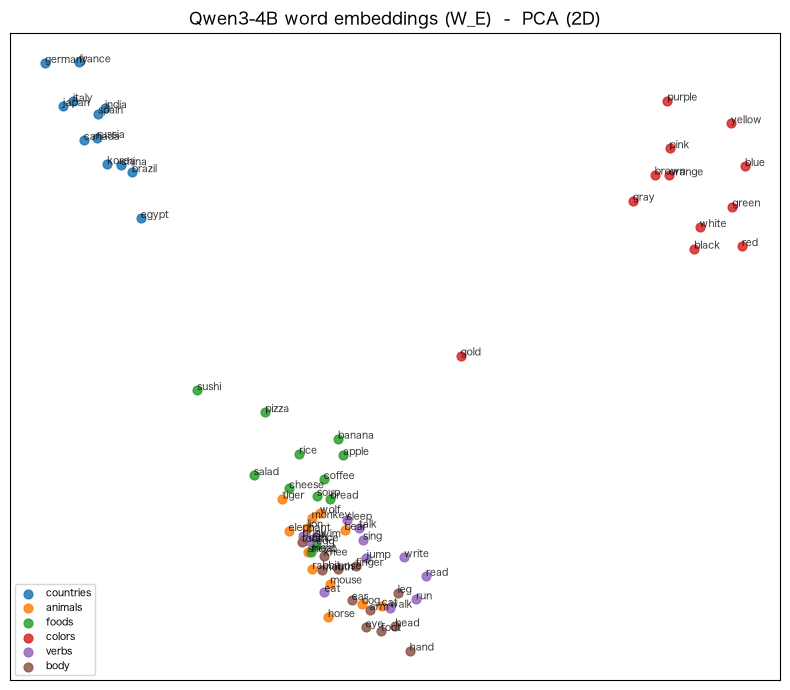

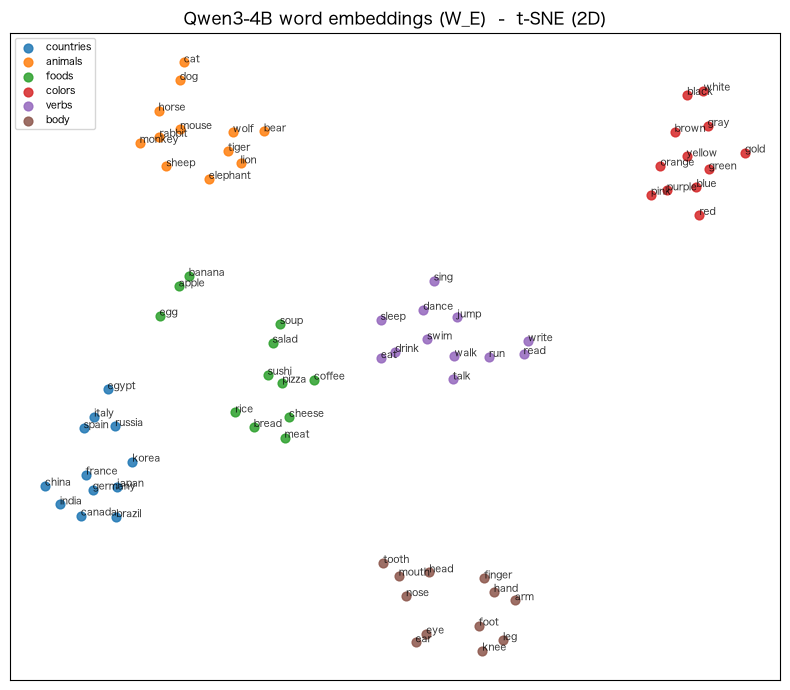

In [18]:
# §5 で見た語彙埋め込み W_E を「単語ベクトル」として可視化する。
# 1 token で 1 単語になる語を選び、PCA と t-SNE で 2D に落として意味のまとまりを見る。
# （PCA と t-SNE は別々の図として出す。あとで単独で再利用できるようにするため。）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

W_E = model.get_input_embeddings().weight.float().cpu().numpy()   # [vocab, hidden] 入口=出口 tie
print("embedding matrix W_E:", W_E.shape, " tie:", model.config.tie_word_embeddings)

CATEGORIES = {
    "countries": ["japan","china","korea","india","france","germany","italy","brazil","canada","russia","spain","egypt"],
    "animals":   ["cat","dog","horse","elephant","tiger","rabbit","monkey","lion","wolf","sheep","bear","mouse"],
    "foods":     ["pizza","sushi","bread","rice","cheese","banana","coffee","apple","soup","salad","meat","egg"],
    "colors":    ["red","blue","green","yellow","purple","pink","black","white","brown","orange","gray","gold"],
    "verbs":     ["run","walk","jump","sing","write","read","swim","dance","sleep","eat","drink","talk"],
    "body":      ["head","hand","foot","arm","leg","eye","ear","nose","mouth","finger","knee","tooth"],
}

def single_token_id(word):
    # 語頭スペース付きで 1 token になる表記を優先（Qwen/GPT の BPE は語頭に空白を含める流儀）
    for cand in (" " + word, " " + word.capitalize()):
        ids = tokenizer.encode(cand, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    return None

labels, cats, vecs = [], [], []
for cat, ws in CATEGORIES.items():
    for w in ws:
        tid = single_token_id(w)
        if tid is not None:
            labels.append(w); cats.append(cat); vecs.append(W_E[tid])
X = np.array(vecs)
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)   # L2 正規化（norm=頻度成分を除く）
print(f"可視化する単語数: {len(labels)}  ({len(CATEGORIES)} カテゴリ)")

cat_list = list(CATEGORIES.keys())
palette = plt.get_cmap("tab10")
color = {c: palette(i) for i, c in enumerate(cat_list)}

def scatter_2d(emb, name):
    """カテゴリ色分けの 2D 散布図を 1 枚描く（単独再利用できるよう図を分ける）。"""
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in cat_list:
        idx = [i for i, cc in enumerate(cats) if cc == c]
        ax.scatter(emb[idx, 0], emb[idx, 1], s=40, color=color[c], label=c, alpha=0.85)
    for i, w in enumerate(labels):
        ax.text(emb[i, 0], emb[i, 1], w, fontsize=7, alpha=0.8)
    ax.set_title(f"Qwen3-4B word embeddings (W_E)  -  {name}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    fig.savefig(outputs_dir / f"nb02_word_embeddings_{'pca' if 'PCA' in name else 'tsne'}.png", dpi=200)
    plt.show()

# 図1: PCA
pca = PCA(n_components=2, random_state=0).fit_transform(Xn)
scatter_2d(pca, "PCA (2D)")

# 図2: t-SNE
tsne = TSNE(n_components=2, perplexity=8, random_state=0, init="pca").fit_transform(Xn)
scatter_2d(tsne, "t-SNE (2D)")


### 単語数を増やす（カテゴリ・語数を追加）

カテゴリと単語を増やしても、意味のまとまりは保たれる。sports / jobs / vehicles / instruments / clothing
などを加えた約 120 語で、同じ $W_E$ から PCA / t-SNE を描く（こちらも 2 図を別々に出す）。
上の `single_token_id` と `W_E` をそのまま再利用する。


可視化する単語数: 124  (10 カテゴリ)


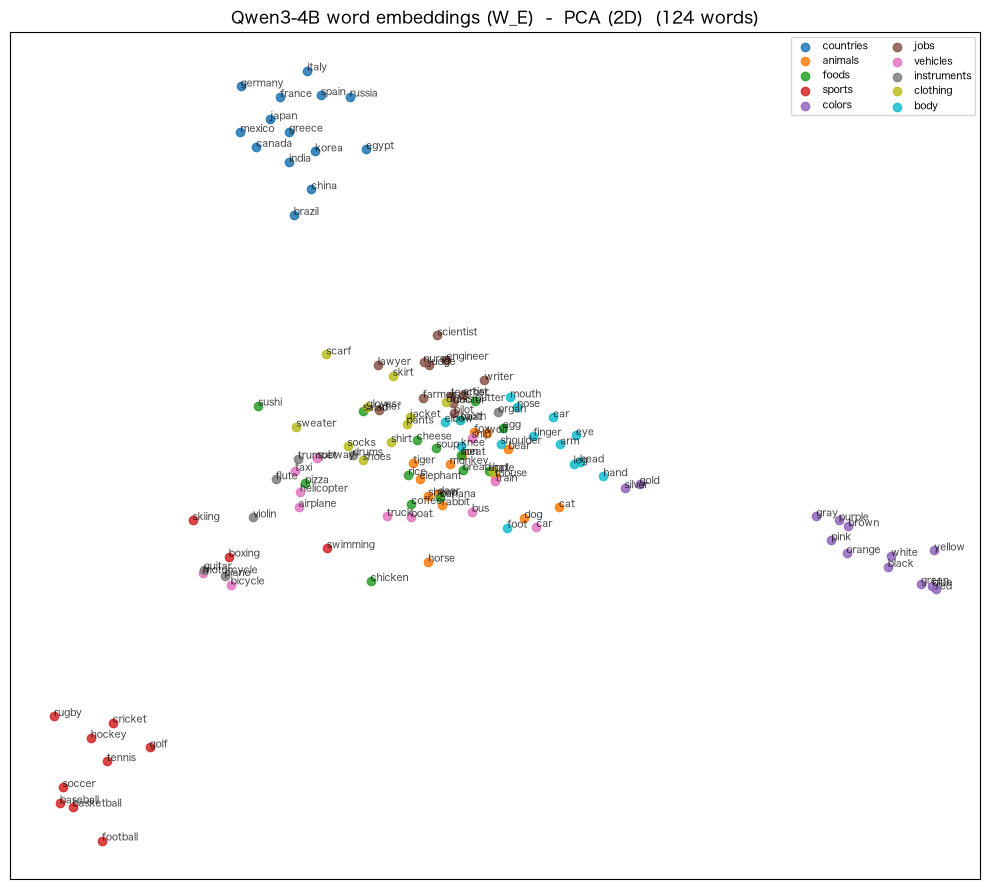

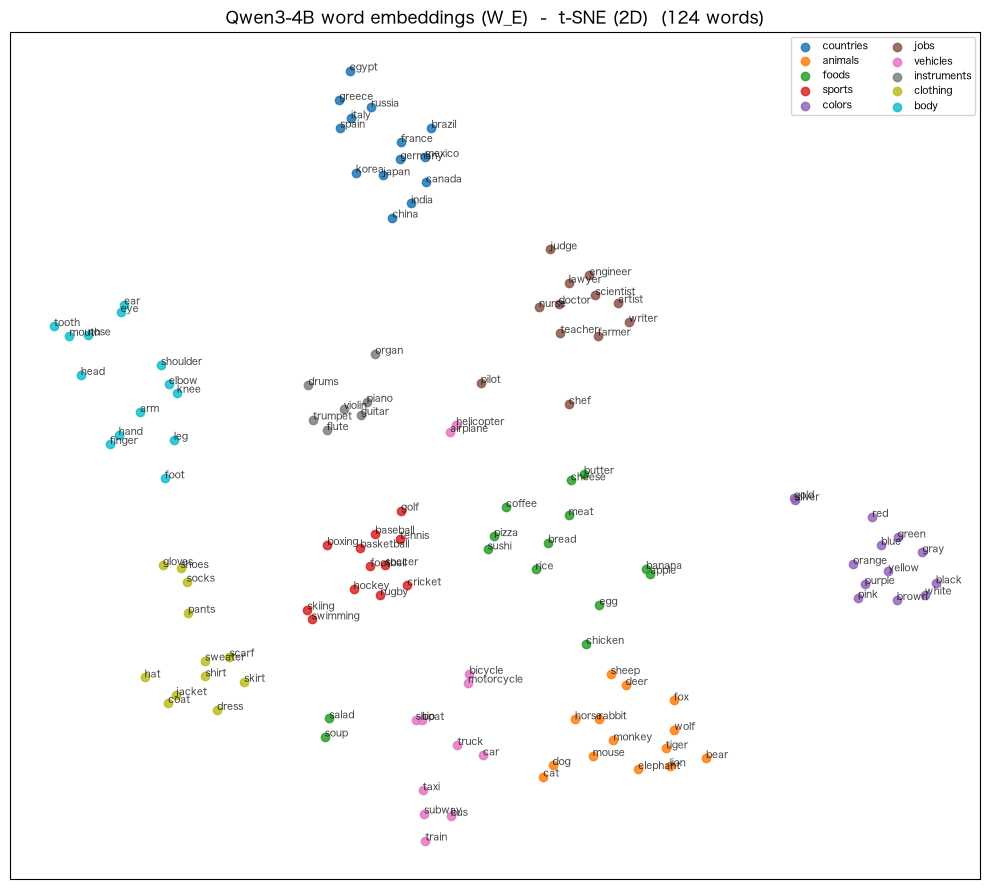

In [19]:
# 単語数を増やした版（10 カテゴリ・約 120 語）。同じ W_E で、より多くの単語の意味空間を見る。
# 上のセルで定義した single_token_id / W_E / np / plt / PCA / TSNE を再利用する。
BIG_CATEGORIES = {
    "countries":   ["japan","china","korea","india","france","germany","italy","brazil","canada","russia","spain","egypt","mexico","greece"],
    "animals":     ["cat","dog","horse","elephant","tiger","rabbit","monkey","lion","wolf","sheep","bear","mouse","fox","deer"],
    "foods":       ["pizza","sushi","bread","rice","cheese","banana","coffee","apple","soup","salad","meat","egg","chicken","butter"],
    "sports":      ["soccer","football","basketball","baseball","tennis","golf","hockey","boxing","rugby","cricket","swimming","skiing"],
    "colors":      ["red","blue","green","yellow","purple","pink","black","white","brown","orange","gray","gold","silver"],
    "jobs":        ["doctor","teacher","nurse","lawyer","engineer","scientist","farmer","chef","pilot","artist","writer","judge"],
    "vehicles":    ["car","truck","bus","train","bicycle","motorcycle","airplane","helicopter","boat","ship","taxi","subway"],
    "instruments": ["piano","guitar","violin","drums","flute","trumpet","cello","harp","clarinet","banjo","organ"],
    "clothing":    ["shirt","pants","dress","jacket","hat","shoes","socks","coat","sweater","scarf","gloves","skirt"],
    "body":        ["head","hand","foot","arm","leg","eye","ear","nose","mouth","finger","knee","tooth","shoulder","elbow"],
}

labels_big, cats_big, vecs_big = [], [], []
for cat, ws in BIG_CATEGORIES.items():
    for w in ws:
        tid = single_token_id(w)
        if tid is not None:
            labels_big.append(w); cats_big.append(cat); vecs_big.append(W_E[tid])
Xb = np.array(vecs_big)
Xbn = Xb / (np.linalg.norm(Xb, axis=1, keepdims=True) + 1e-8)
print(f"可視化する単語数: {len(labels_big)}  ({len(BIG_CATEGORIES)} カテゴリ)")

cat_list_big = list(BIG_CATEGORIES.keys())
palette_big = plt.get_cmap("tab10")
color_big = {c: palette_big(i % 10) for i, c in enumerate(cat_list_big)}

def scatter_big(emb, name):
    """多語版のカテゴリ色分け散布図を 1 枚描く（PCA / t-SNE で別々に呼ぶ）。"""
    fig, ax = plt.subplots(figsize=(10, 9))
    for c in cat_list_big:
        idx = [i for i, cc in enumerate(cats_big) if cc == c]
        ax.scatter(emb[idx, 0], emb[idx, 1], s=36, color=color_big[c], label=c, alpha=0.85)
    for i, w in enumerate(labels_big):
        ax.text(emb[i, 0], emb[i, 1], w, fontsize=7, alpha=0.75)
    ax.set_title(f"Qwen3-4B word embeddings (W_E)  -  {name}  ({len(labels_big)} words)", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc="best", ncol=2)
    fig.tight_layout()
    fig.savefig(outputs_dir / f"nb02_word_embeddings_big_{'pca' if 'PCA' in name else 'tsne'}.png", dpi=200)
    plt.show()

# 図1: PCA
scatter_big(PCA(n_components=2, random_state=0).fit_transform(Xbn), "PCA (2D)")

# 図2: t-SNE
scatter_big(TSNE(n_components=2, perplexity=15, random_state=0, init="pca").fit_transform(Xbn), "t-SNE (2D)")


### 言語をまたぐ：対訳語はどこに来るか

Logit Lens（§8-9）で Qwen3-4B の内部を覗くと、入力は英語 `The capital of Japan is` なのに、
途中の layer で**中国語のトークン**が高い確率で顔を出すことがある。これは、モデルの内部表現が
特定の言語に縛られず、**言語をまたいだ「概念」**を扱っているらしいことを示唆する。

そこで、英語と中国語の**対訳ペア**（`dog`/`狗`, `water`/`水`, …）の埋め込みを比べる。仮説は 2 つ:

- **(a) 対訳が近い**: 同じ概念の EN / ZH がほぼ同じ場所に来る（言語非依存な概念空間）
- **(b) 言語差ベクトル**: EN→ZH が一定方向のオフセットになる（`king − man + woman ≈ queen` 型の加法構成性）

cosine 類似度・最近傍・PCA 2D で、どちらが実際に起きているかを確かめる。


対訳ペア数: 30
対訳ペアの cosine        = 0.631
ランダム異言語ペアの cosine = 0.032


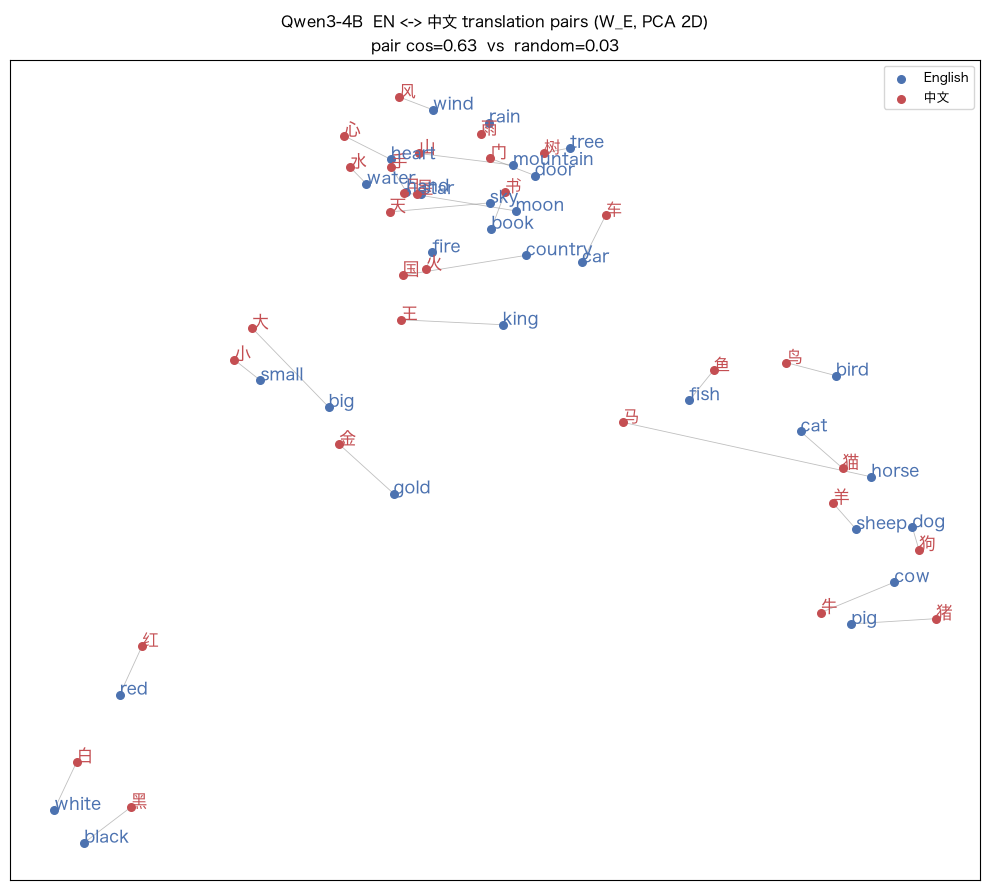

In [20]:
# 言語をまたぐ: 英語↔中国語の対訳ペアが埋め込み空間でどこに来るか。
# 上のセルの single_token_id / W_E / np / plt を再利用。CJK フォントは §1 の早期セルで設定済み。
from sklearn.decomposition import PCA

PAIRS = [
    ("dog","狗"),("cat","猫"),("fish","鱼"),("bird","鸟"),("horse","马"),("cow","牛"),
    ("pig","猪"),("sheep","羊"),("water","水"),("fire","火"),("mountain","山"),("moon","月"),
    ("star","星"),("sky","天"),("rain","雨"),("wind","风"),("country","国"),("king","王"),
    ("book","书"),("hand","手"),("heart","心"),("door","门"),("car","车"),("tree","树"),
    ("red","红"),("white","白"),("black","黑"),("gold","金"),("big","大"),("small","小"),
]

def zh_id(ch):
    for c in (ch, " " + ch):
        ids = tokenizer.encode(c, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    return None

E, Z, kept = [], [], []
for en, zh in PAIRS:
    ei, zi = single_token_id(en), zh_id(zh)      # single_token_id は英語用（上のセルで定義）
    if ei is not None and zi is not None:
        E.append(W_E[ei]); Z.append(W_E[zi]); kept.append((en, zh))
E = np.array(E); Z = np.array(Z)

def cos(a, b): return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))
n = len(kept)
pair_cos = np.mean([cos(E[i], Z[i]) for i in range(n)])
rand_cos = np.mean([cos(E[i], Z[j]) for i in range(n) for j in range(n) if i != j])
print(f"対訳ペア数: {n}")
print(f"対訳ペアの cosine        = {pair_cos:.3f}")
print(f"ランダム異言語ペアの cosine = {rand_cos:.3f}")

# PCA 2D で EN+ZH を並べ、対訳を線で結ぶ
allv = np.vstack([E, Z])
alln = allv / (np.linalg.norm(allv, axis=1, keepdims=True) + 1e-8)
P = PCA(n_components=2, random_state=0).fit_transform(alln)
Pe, Pz = P[:n], P[n:]

fig, ax = plt.subplots(figsize=(10, 9))
for i in range(n):
    ax.plot([Pe[i,0], Pz[i,0]], [Pe[i,1], Pz[i,1]], color="gray", lw=0.6, alpha=0.5, zorder=1)
ax.scatter(Pe[:,0], Pe[:,1], s=30, color="#4C72B0", label="English", zorder=2)
ax.scatter(Pz[:,0], Pz[:,1], s=30, color="#C44E52", label="中文", zorder=2)
for i, (en, zh) in enumerate(kept):
    ax.text(Pe[i,0], Pe[i,1], en, fontsize=12, color="#4C72B0")
    ax.text(Pz[i,0], Pz[i,1], zh, fontsize=12, color="#C44E52")
ax.set_title(f"Qwen3-4B  EN <-> 中文 translation pairs (W_E, PCA 2D)\n"
             f"pair cos={pair_cos:.2f}  vs  random={rand_cos:.2f}",
             fontsize=11)
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(outputs_dir / "nb02_crosslingual_en_zh.png", dpi=200)
plt.show()


**結果**: 対訳ペアの cosine（≈0.6）はランダムな異言語ペア（≈0、ほぼ直交）よりはるかに高く、
対訳ペアどうしが際立って近い（最も近い異言語トークンとして訳語が浮かびやすい）。一方で言語差ベクトル EN→ZH の向きは
一定しない（加法構成性は弱い）。少なくともこの範囲では、**(a) 言語をまたいで同じ概念がほぼ同じ場所に来る**ことを示唆する。
上の PCA 図でも、動物・色・自然などの意味クラスタが **EN / ZH 混在**で形成されている。

これは、英語プロンプトの Logit Lens に中国語トークンが顔を出すことの一因かもしれない。内部表現は
「英語」「中国語」という区別よりも手前の、**言語にあまり依存しない概念**に近い形になっている可能性がある。


### 多言語に広げる：英語ハブの star

対訳が近いのは中国語だけの話ではない。同じ概念を **7 言語**（英語・中国語・日本語・韓国語・
フランス語・スペイン語・ドイツ語）で用意し、**英語を中心 (hub)** に、単語ごとに *単一トークンになる*
言語だけをリンクする（三角形にはせず、英語↔各言語の spoke のみ）。t-SNE で 2D に落とす。

各概念が**言語をまたいで一つのまとまり**を作れば、「言語ではなく概念で並ぶ」ことを示唆する。
（ロシア語などは単一トークンにならない語が多く、その言語は単語ごとに自動的に外れる。CJK・ハングルの
表示には §1 で設定した多言語フォントを使う。）


points = 119   coverage(単一トークンだった語数/言語) = {'en': 22, 'zh': 22, 'ja': 21, 'ko': 16, 'fr': 12, 'es': 12, 'de': 14}


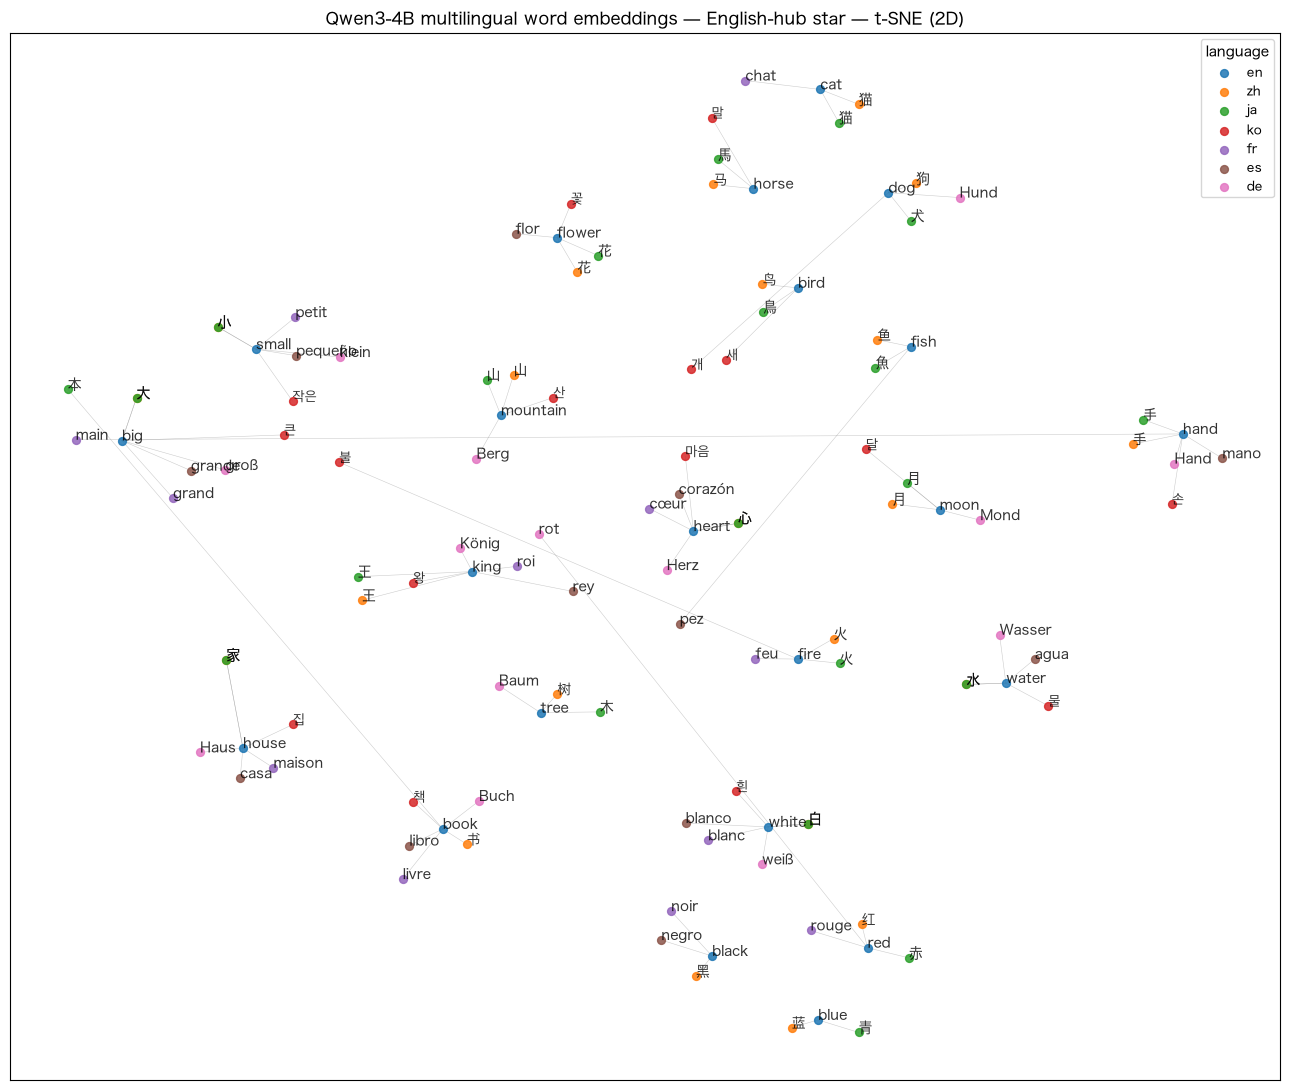

In [21]:
# 多言語・英語ハブ star（t-SNE のみ）。単語ごとに単一トークンの言語だけを英語にリンクする。
# CJK/ハングルのフォントは §1 の早期セルで設定済み。W_E / np / plt を再利用。
from sklearn.manifold import TSNE

LANGS = ["en", "zh", "ja", "ko", "fr", "es", "de"]
# concept -> [en, zh, ja, ko, fr, es, de]
MULTI = {
    "dog":     ["dog","狗","犬","개","chien","perro","Hund"],
    "cat":     ["cat","猫","猫","고양이","chat","gato","Katze"],
    "fish":    ["fish","鱼","魚","물고기","poisson","pez","Fisch"],
    "bird":    ["bird","鸟","鳥","새","oiseau","pájaro","Vogel"],
    "horse":   ["horse","马","馬","말","cheval","caballo","Pferd"],
    "water":   ["water","水","水","물","eau","agua","Wasser"],
    "fire":    ["fire","火","火","불","feu","fuego","Feuer"],
    "moon":    ["moon","月","月","달","lune","luna","Mond"],
    "mountain":["mountain","山","山","산","montagne","montaña","Berg"],
    "tree":    ["tree","树","木","나무","arbre","árbol","Baum"],
    "flower":  ["flower","花","花","꽃","fleur","flor","Blume"],
    "book":    ["book","书","本","책","livre","libro","Buch"],
    "house":   ["house","家","家","집","maison","casa","Haus"],
    "king":    ["king","王","王","왕","roi","rey","König"],
    "hand":    ["hand","手","手","손","main","mano","Hand"],
    "heart":   ["heart","心","心","마음","cœur","corazón","Herz"],
    "red":     ["red","红","赤","빨강","rouge","rojo","rot"],
    "white":   ["white","白","白","흰","blanc","blanco","weiß"],
    "black":   ["black","黑","黒","검정","noir","negro","schwarz"],
    "blue":    ["blue","蓝","青","파랑","bleu","azul","blau"],
    "big":     ["big","大","大","큰","grand","grande","groß"],
    "small":   ["small","小","小","작은","petit","pequeño","klein"],
}

def tok1(s):
    # 先頭スペース付き(Latin の語中トークン)を優先し、無ければ素の文字列(CJK 単漢字)を試す
    for c in (" " + s, s):
        ids = tokenizer.encode(c, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    return None

pts = []   # (concept, lang, word, vec)
for concept, forms in MULTI.items():
    for L, w in zip(LANGS, forms):
        i = tok1(w)
        if i is not None:
            pts.append((concept, L, w, W_E[i]))
V = np.array([p[3] for p in pts])
Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-8)
cov = {L: sum(1 for p in pts if p[1] == L) for L in LANGS}
print(f"points = {len(pts)}   coverage(単一トークンだった語数/言語) = {cov}")

emb = TSNE(n_components=2, perplexity=10, random_state=0, init="pca").fit_transform(Vn)
idx = {(p[0], p[1]): k for k, p in enumerate(pts)}
palette = plt.get_cmap("tab10")
lcolor = {L: palette(i) for i, L in enumerate(LANGS)}

fig, ax = plt.subplots(figsize=(13, 11))
# 英語ハブ star: 各概念で en を中心に各言語へ spoke（三角形にはしない）
for concept in MULTI:
    if (concept, "en") not in idx:
        continue
    h = idx[(concept, "en")]
    for L in LANGS:
        if L != "en" and (concept, L) in idx:
            k = idx[(concept, L)]
            ax.plot([emb[h,0], emb[k,0]], [emb[h,1], emb[k,1]],
                    color="gray", lw=0.4, alpha=0.4, zorder=1)
for L in LANGS:
    ks = [k for k, p in enumerate(pts) if p[1] == L]
    ax.scatter(emb[ks,0], emb[ks,1], s=32, color=lcolor[L], label=L, alpha=0.85, zorder=2)
for k, p in enumerate(pts):
    ax.text(emb[k,0], emb[k,1], p[2], fontsize=10, alpha=0.8)
ax.set_title("Qwen3-4B multilingual word embeddings — English-hub star — t-SNE (2D)", fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=9, title="language")
fig.tight_layout()
fig.savefig(outputs_dir / "nb02_multilingual_star.png", dpi=200)
plt.show()


## 7. residual stream と hidden_states の対応

前節では、入口の embedding と出口の `lm_head` / softmax を確認しました。  
ここからは、その中間を流れる hidden state の系列 $h_t^{(0)}, h_t^{(1)}, \dots, h_t^{(K)}$ を **residual stream** として見ていきます。

Hugging Face Transformers の `outputs.hidden_states` は長さ $K + 1$ のタプルで、その第 $k$ 要素 `hidden_states[k]`（このノートでは `clean_hs[k]`）が、$h_t^{(k)}$ を $t = 0, 1, \dots, T-1$ について並べた `[1, T, d]` テンソルに対応します。


In [22]:
print(f"K = {K}")
print(f"len(clean_hs) = {len(clean_hs)}  (= K+1 = {K}+1)")
print(f"hs[0].shape   = {tuple(clean_hs[0].shape)}  <- embed_tokens 出力")
print(f"hs[1].shape   = {tuple(clean_hs[1].shape)}  <- layer 0 出力")
print(f"hs[K].shape   = {tuple(clean_hs[K].shape)}  <- norm 後 (k=K)")
print()
print("Residual stream のインデックス対応:")
print("  hs[0]   = embed_tokens(input_ids)")
print("  hs[k]   = layers[k-1] の出力  (1 <= k <= K-1)")
print(f"  hs[{K}]  = model.model.norm(layers[{K-1}] の出力)  ← lm_head の直前")

K = 36
len(clean_hs) = 37  (= K+1 = 36+1)
hs[0].shape   = (1, 5, 2560)  <- embed_tokens 出力
hs[1].shape   = (1, 5, 2560)  <- layer 0 出力
hs[K].shape   = (1, 5, 2560)  <- norm 後 (k=K)

Residual stream のインデックス対応:
  hs[0]   = embed_tokens(input_ids)
  hs[k]   = layers[k-1] の出力  (1 <= k <= K-1)
  hs[36]  = model.model.norm(layers[35] の出力)  ← lm_head の直前


### logit lens の読み出し関数

本来の目的である、言語モデルによる推論（テキストの生成）では、logit lens は不要です。logit lens は、言語モデルの内部で情報がどのように処理されているかを調べるための**解析ツール**です。途中層の hidden state $h_t^{(k)}$ を見ても、それが何を表すのかわかりませんが、$h_t^{(k)}$ を出口と同じ仕組みで vocabulary 全体の score に変換することで、「その時点でのモデルの予測」として解釈できるようになります。これを **logit lens** と呼びます。[nostalgebraist. (2020)](#ref-nostalgebraist-2020)のブログ記事が元アイデアとなり、言語モデル研究のmechanistic interpretability分野で広く使われる。

具体的には、`lm_head` の直前に置かれている final RMSNorm $\mathrm{Norm}(\cdot)$（PyTorch では `model.model.norm` に対応）と unembedding $W_U$ を組み合わせて、$h_t^{(k)}$ を vocabulary 全体の logits に変換します。

$$
z_t^{(k)}
= W_U \, \mathrm{Norm}(h_t^{(k)})
\in \mathbb{R}^M
\quad (0 \le k \le K-1)
$$

最終層 $k = K$ については、Hugging Face Transformers の `outputs.hidden_states[K]` (= `clean_hs[-1]`) がすでに $\mathrm{Norm}$ 適用後のテンソルなので、追加の norm は不要で、

$$
z_t^{(K)} = W_U \, h_t^{(K)} = z_t
$$

となり、forward pass の最終 logits $z_t$ と一致します（次セルの sanity check で確認します）。

なお、ここでの $k$ の場合分け（$k < K$ で Norm 必要、$k = K$ で不要）は、前セルで述べた `hs[k]` の由来による分類（embed 出力 / layer 出力 / norm 後）とは異なり、`lm_head` 直前の Norm 適用の有無だけで決まります。

各層の「途中段階の予測分布」は、softmax をかけて

$$
p_t^{(k)} = \mathrm{softmax}(z_t^{(k)}) \in \mathbb{R}^M
$$

として得ます。

次に定義する `logit_lens(hidden_states, k, pos)` は、この $z_t^{(k)}$ を $k < K$ と $k = K$ で場合分けして計算します。続く `logit_lens_sweep(hidden_states, pos)` は、全ての $k = 0, 1, \dots, K$ について $z_t^{(k)}$ と $p_t^{(k)}$ を計算し、top-1 token などとともに DataFrame にまとめます。なお、いずれの関数も `model` と `tokenizer` はこの notebook 共通のものを外スコープから直接参照します。


In [23]:
# Logit Lens の計算
def logit_lens(hidden_states, k: int, pos: int) -> torch.Tensor:
    """
    残差ストリームの layer k を「その時点でのモデルの予測」として読むために，
    その時点での hidden state を lm_head に通した logits を返す。
    k = K だけ処理が異なることに注意する。

    hidden_states のインデックス対応:
      hs[0]   = embed_tokens の出力
      hs[k]   = layers[k-1] の出力  （1 <= k <= K-1）
      hs[K]   = model.model.norm 後  （lm_head の直前）

    k < K の場合は norm を通してから lm_head に入力する。
    k = K の場合は hs[K] が既に norm 後なので直接 lm_head に入力する。

    model と tokenizer は外スコープのものを参照する。
    """
    K = len(hidden_states) - 1  # Qwen3-4B では K=36
    hs = hidden_states[k]       # shape: [1, seq, hidden_size]

    if k < K:
        # pos:pos+1 でスライスして [1, 1, hidden_size] にしてから norm を適用
        normed = model.model.norm(hs[:, pos:pos+1, :])  # [1, 1, hidden_size]
        logits = model.lm_head(normed)[:, 0, :]          # [1, vocab]
    else:
        # k == K: hs[K] は既に norm 済み。pos だけ取り出して lm_head へ
        normed = hs[:, pos, :]         # [1, hidden_size]
        logits = model.lm_head(normed) # [1, vocab]

    return logits[0]  # [vocab]


# 全 layer の logit lens を sweep して DataFrame を返す
def logit_lens_sweep(hidden_states, pos: int) -> pd.DataFrame:
    """hidden_states の各層を logit lens で読み、確率等をまとめた DataFrame を返す。"""
    K_loc = len(hidden_states) - 1
    rows = []
    for k in range(K_loc + 1):
        ll_logits    = logit_lens(hidden_states, k, pos)
        ll_probs     = torch.softmax(ll_logits.float(), dim=-1)
        top1_id      = int(ll_logits.argmax().item())
        top1_decoded = tokenizer.decode([top1_id])
        site = "embed" if k == 0 else (f"L{k-1:02d}" if k < K_loc else "norm")
        rows.append({
            "k":            k,
            "site":         site,
            "top1_decoded": repr(top1_decoded),
            "p_top1":       ll_probs[top1_id].item(),
            "p_clean":      ll_probs[CLEAN_ANS_ID].item(),
            "p_corrupt":    ll_probs[CORRUPT_ANS_ID].item(),
        })
    return pd.DataFrame(rows)


### logit lens の sanity check：k=K は最終出力と一致する

Section 5 で見たとおり、$z_t^{(K)} = W_U \, h_t^{(K)} = z_t$ が成り立つはずです。`logit_lens(clean_hs, K, clean_pos)` の出力が forward pass の最終 logits `clean_logits` と（誤差の範囲で）一致することを確認します。


In [24]:
# hs[K] (norm 後) を lm_head に通した結果と model output logits を比較
ll_logits_K = logit_lens(clean_hs, K, clean_pos)
display(topk_table(ll_logits_K, k=5).style.set_caption("logit_lens(k=K)"))
display(topk_table(clean_logits, k=5).style.set_caption("model output logits"))

diff = (ll_logits_K - clean_logits).abs().max().item()
print(f"logit_lens(k=K) vs model logits: max abs diff = {diff:.6f}")
print("  diff ≈ 0 なら logit_lens の実装が正しい")

,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502


,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502


logit_lens(k=K) vs model logits: max abs diff = 0.000000
  diff ≈ 0 なら logit_lens の実装が正しい


## 8. Logit Lens — clean run

Section 7 で定義した `logit_lens` / `logit_lens_sweep` を、clean prompt (`The capital of Japan is`) に適用します。各 layer $k$ で hidden state を `lm_head` に通したときに、target token `" Tokyo"` の確率や順位がどの層で立ち上がるかを観察します。

最後の position に注目した曲線と、全 position を grid 状に並べた可視化の 2 つの形式で見ます。


### 最後の position の logit lens

最後の position（入力末尾の `" is"` の直後）に絞って、layer ごとの logit lens を見ます。target token `" Tokyo"` の確率 P(Tokyo) と、比較として `" Paris"` の確率 P(Paris) が、layer を進むにつれてどう変化するかを曲線で確認します。


In [25]:
# clean run
df_ll_clean = logit_lens_sweep(clean_hs, clean_pos)
display(df_ll_clean.set_index("k").style.set_caption("Logit Lens — clean run").format({"p_top1": "{:.4f}", "p_clean": "{:.4f}", "p_corrupt": "{:.4f}"}))

,site,top1_decoded,p_top1,p_clean,p_corrupt
k,,,,,
0,embed,' is',1.0000,0.0000,0.0000
1,L00,'/is',0.1505,0.0000,0.0000
2,L01,'紋',0.0680,0.0000,0.0000
3,L02,'rael',0.0536,0.0000,0.0000
4,L03,'abella',0.0239,0.0000,0.0000
5,L04,'rael',0.0277,0.0000,0.0000
6,L05,'rael',0.0187,0.0000,0.0000
7,L06,'mé',0.0211,0.0000,0.0000
8,L07,'mé',0.1281,0.0000,0.0000


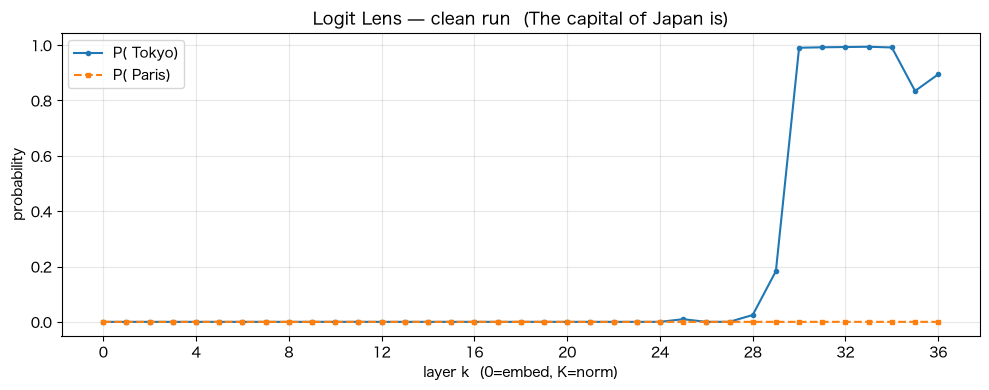

Saved: nb02_logit_lens_clean.png


In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_ll_clean["k"], df_ll_clean["p_clean"], label=f"P({CLEAN_ANSWER})", marker="o", markersize=3)
ax.plot(df_ll_clean["k"], df_ll_clean["p_corrupt"], label=f"P({CORRUPT_ANSWER})", marker="s", markersize=3, linestyle="--")
ax.set_xlabel("layer k  (0=embed, K=norm)")
ax.set_ylabel("probability")
ax.set_title(f"Logit Lens — clean run  ({CLEAN_PROMPT})")
ax.legend()
ax.set_xticks(range(0, K + 1, 4))
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = outputs_dir / "nb02_logit_lens_clean.png"
plt.savefig(out, dpi=300)
plt.show()
print(f"Saved: {out.name}")


**観察**：clean run では入力に `Japan` が含まれるため、後半の layer ほど P(Tokyo) が立ち上がり、P(Paris) は低く保たれることが期待されます。どの layer から P(Tokyo) が顕著に上がるか、最終層に近づくと飽和するかに注目してください。


### 全 position の logit lens：top-1 token と target rank

clean prompt のすべての position に対して、layer ごとの logit lens を grid 図として可視化します。

この図は **teacher forcing** による可視化です。つまり、入力 token 列を固定して一度 forward し、各 position / layer の hidden state を読みます。これは生成ループではありません。ただし causal language model では、position $t$ の hidden state は $x_0, x_1, \dots, x_t$ までに基づくため、未来 token を見ているわけではありません。

各セルの文字は、その layer / position で logit lens が top-1 として読んだ token です。  
セルの色は、本来の next token（target）が vocabulary 全体の中で何位にいるか（target rank）を表します。target が 1 位なら最も明るく、最下位なら最も暗くなります。値の差を見やすくするため、色は rank の対数スケールで正規化しています（rank = 1, 10, 100, 1000, ... が等間隔に並ぶ）。

枠線が付いたセルでは、top-1 token が target token と一致しています。


**helper 関数の定義**：以降の grid 図で使う 2 つの関数を定義します。`short_piece` は token を表示用の短い文字列に整形するヘルパー、`plot_logit_lens_grid` は `(layer, position)` の grid heatmap を作る関数です。これらは clean prompt だけでなく、Section 9 の corrupt prompt でも再利用します。


In [27]:
# 図の helper 関数：短い token piece 表示と logit lens grid 描画
import math
import numpy as np
from matplotlib.patches import Rectangle

# フォント/CJK/RTL 設定は §1 の「多言語フォント設定」セルで実施済み（short_piece が _fix_rtl を使う）

def short_piece(token_id: int, max_len: int = 10) -> str:
    """token id を表示用の短い文字列に変換（改行・空文字・長すぎる token を整形）。
    BMP 外（U+10000 以上、絵文字や国旗構成文字など）は通常フォントに無いため
    プレースホルダ □ に置換し、matplotlib の Glyph missing warning を防ぐ。
    """
    s = tokenizer.decode([int(token_id)])
    s = s.replace("\n", "\\n").replace("\t", "\\t")
    s = "".join(c if ord(c) < 0x10000 else "□" for c in s)
    if s == "":
        s = "∅"
    if len(s) > max_len:
        s = s[:max_len] + "…"
    return _fix_rtl(s)


def plot_logit_lens_grid(
    hidden_states,
    input_ids,
    target_ids,
    title: str,
    out_path=None,
):
    """各 (layer k, position t) で logit lens の top-1 token と target rank を計算し、
    heatmap として描画する。

    Args:
        hidden_states: forward の hidden_states タプル（clean_hs / corrupt_hs 等）
        input_ids:     入力 token ID 列（Python list、長さ T）
        target_ids:    各 position の target token ID 列（list、長さ T）
        title:         図のタイトル
        out_path:      PNG 保存先（None なら保存しない）

    Returns:
        (fig, info) — info は grid_text / rank_score / target_rank / top1_match を含む dict
    """
    K_loc = len(hidden_states) - 1
    T = len(input_ids)
    vocab_size = model.config.vocab_size
    log_M = math.log10(vocab_size)

    grid_text, rank_score, target_rank, top1_match = [], [], [], []
    for k in range(K_loc + 1):
        row_t, row_s, row_r, row_m = [], [], [], []
        for pos in range(T):
            logits = logit_lens(hidden_states, k, pos).float().detach().cpu()
            target_id = int(target_ids[pos])
            target_logit = logits[target_id].item()
            rank = int((logits > target_logit).sum().item()) + 1
            top1_id = int(logits.argmax().item())
            score = 1.0 - math.log10(rank) / log_M
            row_t.append(short_piece(top1_id))
            row_s.append(score)
            row_r.append(rank)
            row_m.append(top1_id == target_id)
        grid_text.append(row_t)
        rank_score.append(row_s)
        target_rank.append(row_r)
        top1_match.append(row_m)

    score_arr = np.array(rank_score)
    match_arr = np.array(top1_match)

    fig_width  = max(8.0, 1.6 * T)
    fig_height = max(10.0, 0.28 * (K_loc + 1))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = plt.get_cmap("viridis")
    im = ax.imshow(score_arr, aspect="auto", vmin=0.0, vmax=1.0, cmap=cmap, origin="lower")
    ax.set_title(title)
    ax.set_xlabel("Position: input token → target next token")
    ax.set_ylabel("Layer k")

    xlabels = [
        f"{short_piece(int(input_ids[t]))}→{short_piece(int(target_ids[t]))}"
        for t in range(T)
    ]
    ax.set_xticks(range(T))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ylabels = []
    for k in range(K_loc + 1):
        if k == 0:
            ylabels.append("0 emb")
        elif k == K_loc:
            ylabels.append(f"{k} norm")
        else:
            ylabels.append(str(k))
    ax.set_yticks(range(K_loc + 1))
    ax.set_yticklabels(ylabels)

    # 文字色を cell の輝度で適応的に切り替え（暗いセルでは白、明るいセルでは黒）
    for k in range(K_loc + 1):
        for pos in range(T):
            rgba = cmap(score_arr[k, pos])
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if lum < 0.5 else "black"
            ax.text(pos, k, grid_text[k][pos],
                    ha="center", va="center", fontsize=7, color=text_color)
            if match_arr[k, pos]:
                ax.add_patch(Rectangle(
                    (pos - 0.5, k - 0.5), 1, 1,
                    fill=False, edgecolor="red", linewidth=1.8,
                ))

    cbar = fig.colorbar(im, ax=ax)
    rank_ticks = [1, 10, 100, 1000, 10000, vocab_size]
    score_ticks = [1.0 - math.log10(r) / log_M for r in rank_ticks]
    cbar.set_ticks(score_ticks)
    cbar.set_ticklabels([f"{r:,}" for r in rank_ticks])
    cbar.set_label("target rank (log scale)")
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200)
        print(f"saved: {out_path.name}")

    info = {
        "grid_text":   grid_text,
        "rank_score":  rank_score,
        "target_rank": target_rank,
        "top1_match":  top1_match,
    }
    return fig, info


**clean prompt への適用**：clean prompt の input token 列と、各 position の target token（teacher forcing による次の input token、最後の position のみ `CLEAN_ANS_ID`）を準備し、上で定義した `plot_logit_lens_grid` を呼び出して grid 図を生成します。


,position,input_token_id,input_token,target_token_id,target_next_token
0,0,785,The,6722,capital
1,1,6722,capital,315,of
2,2,315,of,6323,Japan
3,3,6323,Japan,374,is
4,4,374,is,26194,Tokyo


saved: nb02_logit_lens_grid_clean.png


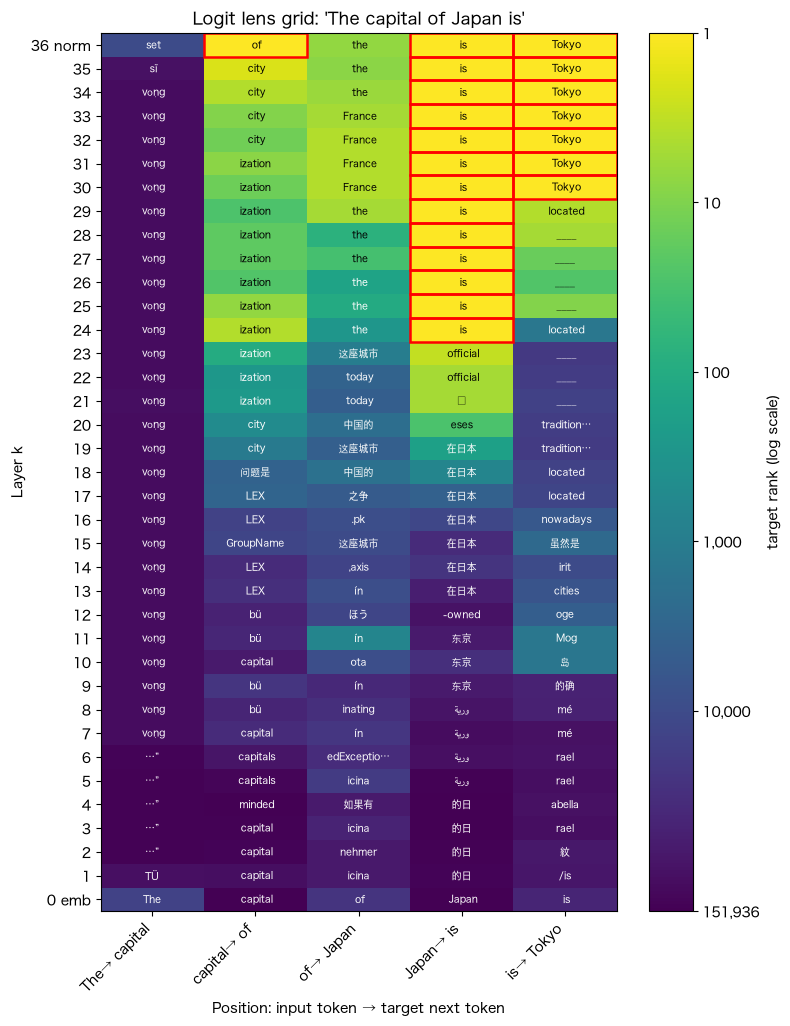

In [28]:
# clean prompt 側の target 準備と grid 描画
input_ids_clean = clean_inputs["input_ids"][0].detach().cpu().tolist()
T = len(input_ids_clean)

# 各 position の target = 次 position の input。最終 position は CLEAN_ANS_ID
target_ids = input_ids_clean[1:] + [CLEAN_ANS_ID]

target_rows = []
for pos, (inp_id, tgt_id) in enumerate(zip(input_ids_clean, target_ids)):
    target_rows.append({
        "position":          pos,
        "input_token_id":    int(inp_id),
        "input_token":       short_piece(inp_id),
        "target_token_id":   int(tgt_id),
        "target_next_token": short_piece(tgt_id),
    })
target_df = pd.DataFrame(target_rows)
display(target_df.style.set_caption("teacher forcing: input → target next token"))

# clean prompt に対して描画
fig, info_clean = plot_logit_lens_grid(
    clean_hs, input_ids_clean, target_ids,
    title=f"Logit lens grid: {CLEAN_PROMPT!r}",
    out_path=outputs_dir / "nb02_logit_lens_grid_clean.png",
)
plt.show()


**観察**：この図は、clean prompt `The capital of Japan is` に対して、すべての position と layer で logit lens（[nostalgebraist, 2020](#ref-nostalgebraist-2020)）を適用した結果を示している。横軸は input token とその次に予測すべき target token の対応を表し、たとえば `Japan→is` は、token `Japan` の位置の hidden state から次 token `is` を予測することを意味する。縦軸は layer を表し、`0 emb` は embedding 直後、`36 norm` は最終層後の正規化後の表現を表す。

この可視化は **teacher forcing** によるものである。つまり、入力 token 列を固定して一度 forward し、各 position / layer の hidden state を読み出している。生成ループで token を逐次生成しているわけではない。ただし causal language model では、position $t$ の hidden state は $x_0, x_1, \dots, x_t$ までに基づいて計算されるため、未来 token を見ているわけではない。

各セルの文字は、その layer / position の hidden state に logit lens を適用したとき、top-1 として読まれた token である。セルの色は、本来の next token、すなわち target token が vocabulary 全体の中で何位にいるかを表す。明るいほど target rank が高く、最も明るい黄色は target token が 1 位に近いことを意味する。色は rank の対数スケールで正規化しているため、rank = 1, 10, 100, 1000, ... の違いが見やすくなっている。赤い枠線が付いたセルでは、logit lens の top-1 token が target token と一致している。

図を見ると、embedding 直後の layer 0 では target rank が低い position もあるが、層が進むにつれて target token の rank が上がり、後半の layer では top-1 一致も増える。特に `Japan→is` や `is→Tokyo` では、後半層で正しい target token が安定して上位に現れている。これは、層を重ねるにつれて、次 token 予測に必要な情報が hidden state に形成されていく様子を示している。

一方で、この図で特に興味深いのは、英語 prompt `The capital of Japan is` に対しても、中間層の logit lens top-1 として `在日本`（日本に／日本で）、`东京`（中国語の簡体字で「東京」）、`这座城市`（この都市）のような中国語・漢字圏 token が現れている点である。つまり、Qwen3-4B（[Qwen Team, 2025](#ref-qwen-2025)）の中間層の hidden state を `lm_head` で読み出すと、英語 token だけでなく、中国語の語彙空間に近い token も上位に現れる場合がある。

この観察は、logit lens を用いて多言語モデルの latent language（潜在言語）を調べる先行研究と対応している。[Wendler et al. (2024)](#ref-wendler-2024) は、Llama-2 系モデルでは、非英語から中国語などへの翻訳タスクであっても、中間層ではまず英語 token が上位に現れ、最終層に近づくにつれて目標言語の token に移ることを報告している。[Schut et al. (2025)](#ref-schut-2025) も、Llama-3.1, Gemma, Mixtral, Aya などの多言語モデルにおいて、意味内容を担う語が中間層で英語 token として現れやすいことを示している。これらは、英語中心モデルでは中間層の表現が英語語彙空間に近い形で読み出されることを示す例である。

一方で、[Zhong et al. (2025)](#ref-zhong-2025) は、主に日本語処理モデルを対象に、非英語中心のモデルの中間層に日本語などの latent language が現れる現象を調べている。本図の Qwen3-4B で、英語 prompt に対しても中間層の表現が中国語・漢字圏の語彙空間に近い token として読み出される観察は、こうした latent language の現象と方向性が一致する。ただし Zhong et al. が Qwen3 の中国語 latent を直接示したわけではなく、ここでは latent language 一般の背景文献として参照している（本図の現象自体は本ノートの自前観察である）。

ただし、logit lens は hidden state を最終出力用の語彙空間に射影して読む解析手法である。そのため、ここで見えている token は内部表現を理解するための手がかりであり、「モデルが内部で中国語に翻訳してから考えている」と断定するものではない。より慎重には、Qwen3-4B のこの例では、中間層の表現が中国語 token として読み出される層が観察された、と解釈するのが適切である。

## 9. Logit Lens 比較 — clean vs corrupt

Section 8 では clean prompt の logit lens を見ました。ここでは同じ手法を corrupt prompt (`The capital of France is`、target = `" Paris"`) にも適用し、clean と corrupt を並べて比較します。後半では確率の代わりに logit-difference metric を導入し、前半・中盤の層の差を見やすくします。


### 最後の position の logit lens：clean vs corrupt

clean prompt と corrupt prompt それぞれの最後の position について、`P(" Tokyo")` と `P(" Paris")` の曲線を並べます。clean では後半 layer で `Tokyo` が、corrupt では `Paris` が高くなることが期待されます。


In [29]:
# corrupt run
df_ll_corrupt = logit_lens_sweep(corrupt_hs, corrupt_pos)
display(df_ll_corrupt.set_index("k").style.set_caption("Logit Lens — corrupt run").format({"p_top1": "{:.4f}", "p_clean": "{:.4f}", "p_corrupt": "{:.4f}"}))

,site,top1_decoded,p_top1,p_clean,p_corrupt
k,,,,,
0,embed,' is',1.0000,0.0000,0.0000
1,L00,'lington',0.1041,0.0000,0.0000
2,L01,'紋',0.0650,0.0000,0.0000
3,L02,'rael',0.0455,0.0000,0.0000
4,L03,'ucht',0.0248,0.0000,0.0000
5,L04,'对学生',0.0183,0.0000,0.0000
6,L05,'ucht',0.0117,0.0000,0.0000
7,L06,' именно',0.0266,0.0000,0.0000
8,L07,'mé',0.1087,0.0000,0.0000


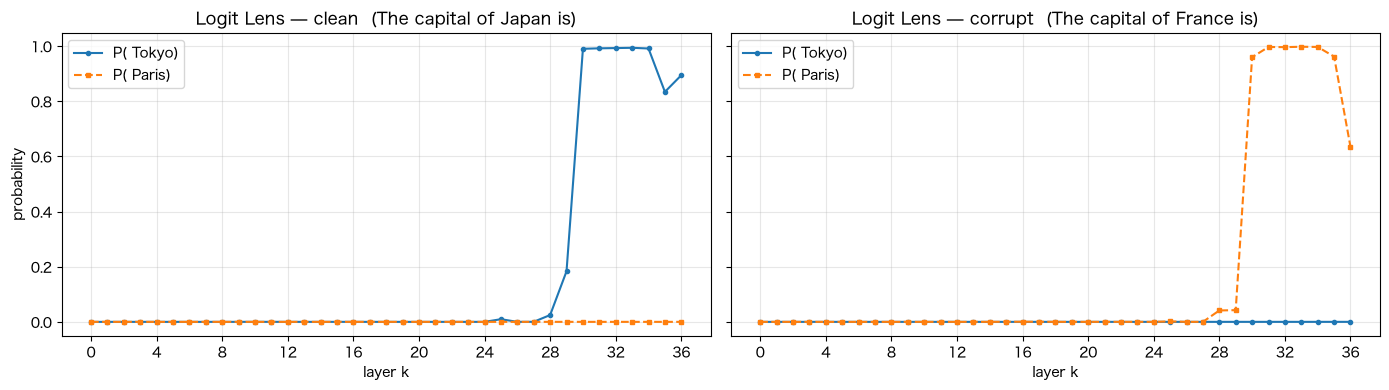

Saved: nb02_logit_lens_comparison.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

ax = axes[0]
ax.plot(df_ll_clean["k"], df_ll_clean["p_clean"], label=f"P({CLEAN_ANSWER})", marker="o", markersize=3)
ax.plot(df_ll_clean["k"], df_ll_clean["p_corrupt"], label=f"P({CORRUPT_ANSWER})", marker="s", markersize=3, linestyle="--")
ax.set_title(f"Logit Lens — clean  ({CLEAN_PROMPT})")
ax.set_xlabel("layer k")
ax.set_ylabel("probability")
ax.legend()
ax.set_xticks(range(0, K + 1, 4))
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_ll_corrupt["k"], df_ll_corrupt["p_clean"], label=f"P({CLEAN_ANSWER})", marker="o", markersize=3)
ax.plot(df_ll_corrupt["k"], df_ll_corrupt["p_corrupt"], label=f"P({CORRUPT_ANSWER})", marker="s", markersize=3, linestyle="--")
ax.set_title(f"Logit Lens — corrupt  ({CORRUPT_PROMPT})")
ax.set_xlabel("layer k")
ax.legend()
ax.set_xticks(range(0, K + 1, 4))
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = outputs_dir / "nb02_logit_lens_comparison.png"
plt.savefig(out, dpi=300)
plt.show()
print(f"Saved: {out.name}")


### 全 position の logit lens：corrupt prompt

Section 8 で導入した logit lens grid 図を、corrupt prompt (`The capital of France is`) でも描いてみます。  
target は teacher forcing による次 token、最後の position だけは `CORRUPT_ANSWER`（= `" Paris"`）です。


saved: nb02_logit_lens_grid_corrupt.png


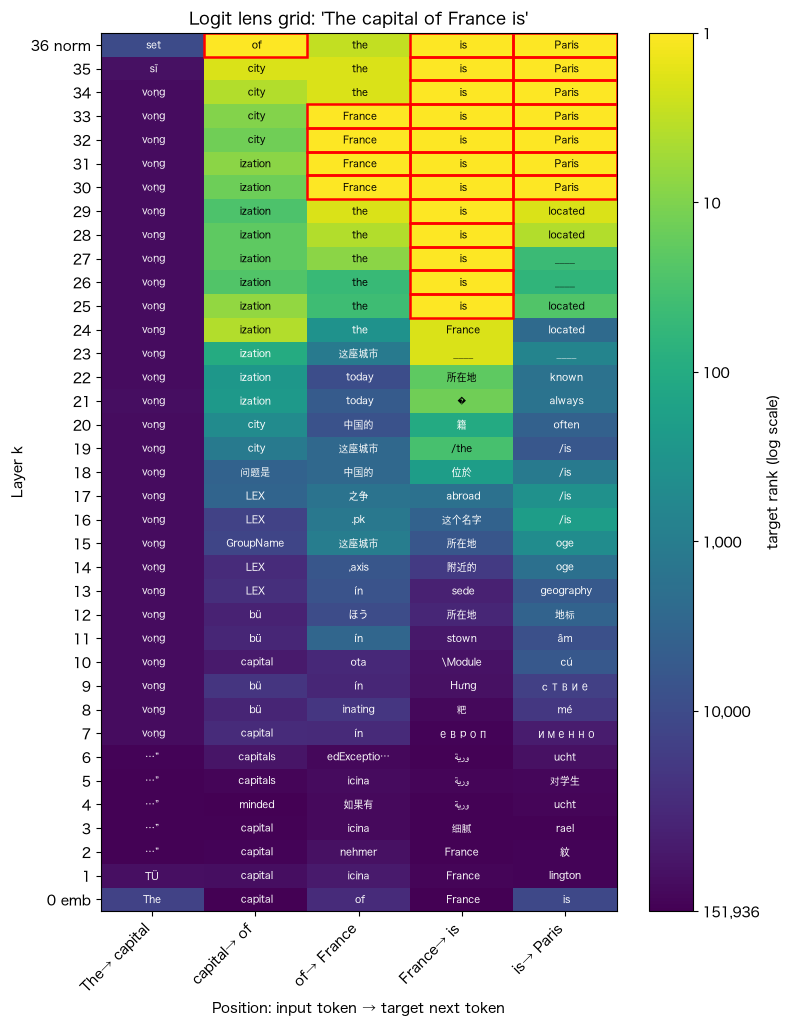

In [31]:
# corrupt prompt 側の target を準備
input_ids_corrupt = corrupt_inputs["input_ids"][0].detach().cpu().tolist()
target_ids_corrupt = input_ids_corrupt[1:] + [CORRUPT_ANS_ID]

fig, info_corrupt = plot_logit_lens_grid(
    corrupt_hs, input_ids_corrupt, target_ids_corrupt,
    title=f"Logit lens grid: {CORRUPT_PROMPT!r}",
    out_path=outputs_dir / "nb02_logit_lens_grid_corrupt.png",
)
plt.show()


**観察**：causal mask により、clean と corrupt で入力 token が一致する最初の 3 position（`The capital of`）の hidden state は、全 layer で同一になります。そのため、これらの position では logit lens で読まれる top-1 token も同じになります。ただし、この図では色が「target next token の rank」を表しているため、3列目（`of→Japan` / `of→France`）では、hidden state は同じでも target が異なり、色は異なります。

clean と corrupt の差が明確に出るのは、position 3（` Japan` / ` France`）以降です。corrupt 側では、最後の position の target `" Paris"` が後半 layer に向けて立ち上がる様子が見えます。また、中間層では `这座城市`（この都市）、`所在地`（所在地／場所）、`位於`（〜に位置する）、`附近的`（近くの／付近の）、`地标`（ランドマーク）のような中国語 token も現れています。これらは、`France` や `Paris` に関係する「都市・場所・位置・ランドマーク」といった意味領域に近く、Qwen3-4B の中間層を logit lens で読むと、中国語の語彙が一時的に上位に現れることを示す興味深い例です。

### logit-difference metric で見る logit lens

確率 plot は後半層で 0/1 に飽和するため、前半・中盤の変化が見えにくい場合がある。
`metric_k = logit_k(" Tokyo") - logit_k(" Paris")` を clean/corrupt で並べると、変化がより見やすくなる。


In [32]:
# ２単語の出現しやすさの差を計算
def metric(logits: torch.Tensor, clean_id: int, corrupt_id: int) -> float:
    """
    logit(clean_answer) - logit(corrupt_answer) を返す。

    この値が大きいほど clean 側の答えが有利な状態。
    recovery の計算に使う基準指標。
    """
    return (logits[clean_id] - logits[corrupt_id]).item()

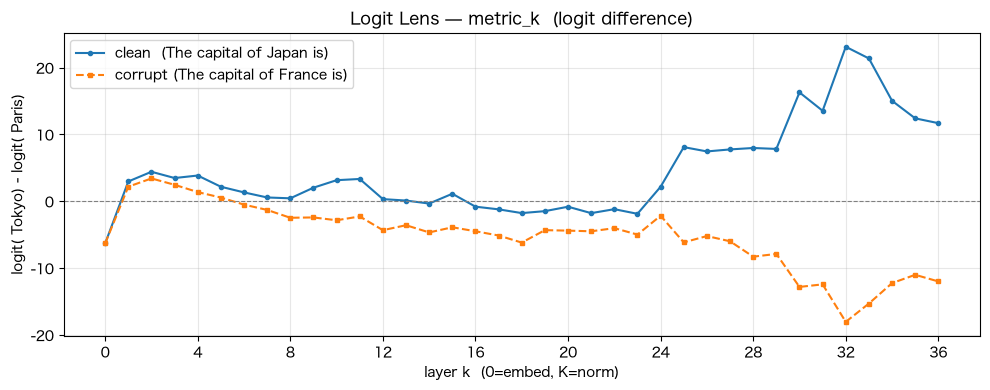

Saved: nb02_logit_lens_metric.png


In [33]:
# logit-difference metric plot (clean / corrupt)
ll_metric_clean   = [
    metric(logit_lens(clean_hs,   k, clean_pos), CLEAN_ANS_ID, CORRUPT_ANS_ID)
    for k in range(K + 1)
]
ll_metric_corrupt = [
    metric(logit_lens(corrupt_hs, k, corrupt_pos), CLEAN_ANS_ID, CORRUPT_ANS_ID)
    for k in range(K + 1)
]

ks = list(range(K + 1))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, ll_metric_clean,   label=f"clean  ({CLEAN_PROMPT})",  marker="o", markersize=3)
ax.plot(ks, ll_metric_corrupt, label=f"corrupt ({CORRUPT_PROMPT})", marker="s", markersize=3, linestyle="--")
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("layer k  (0=embed, K=norm)")
ax.set_ylabel(f"logit({CLEAN_ANSWER}) - logit({CORRUPT_ANSWER})")
ax.set_title("Logit Lens — metric_k  (logit difference)")
ax.legend()
ax.set_xticks(range(0, K + 1, 4))
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = outputs_dir / "nb02_logit_lens_metric.png"
plt.savefig(out, dpi=300)
plt.show()
print(f"Saved: {out.name}")


## 10. Attention の内部：self-attention matrix を覗く

各 Transformer block の attention は、token 同士がどう参照し合うかを表す
**self-attention matrix (SAM)** $A^{(\ell)}_h \in \mathbb{R}^{T\times T}$ を head ごとに持つ:

$$A^{(\ell)}_h[q,k] = \mathrm{softmax}_k\!\left(\frac{Q_q\cdot K_k}{\sqrt{d}}\right)$$

要素は「query token $q$ が key token $k$ をどれだけ参照したか」（行方向で和 $=1$）。causal LM なので
未来 token は見えず（右上は $0$）、行列は**下三角**になる。Qwen3-4B は 1 layer あたり 32 head を持つ。

まず、**役割の違う個別 head を数枚**見てみる。同じ文でも head ごとに「どこを見るか」が全く違う:

- **previous-token**（副対角）: 各 query が直前の token を見る
- **attention sink**（左端の縦ストライプ）: ほぼ全部を先頭 token に捨てる
- **content link**（オフ対角の点）: 離れた 2 つの内容語を結ぶ（ここでは `Tokyo` → `Japan`）

軸は 横 = key（参照される / attended to）、縦 = query（参照する / attending from）。


tokens: ['The', ' capital', ' of', ' Japan', ' is', ' Tokyo']
K=36 layers, n_heads=32, T=6


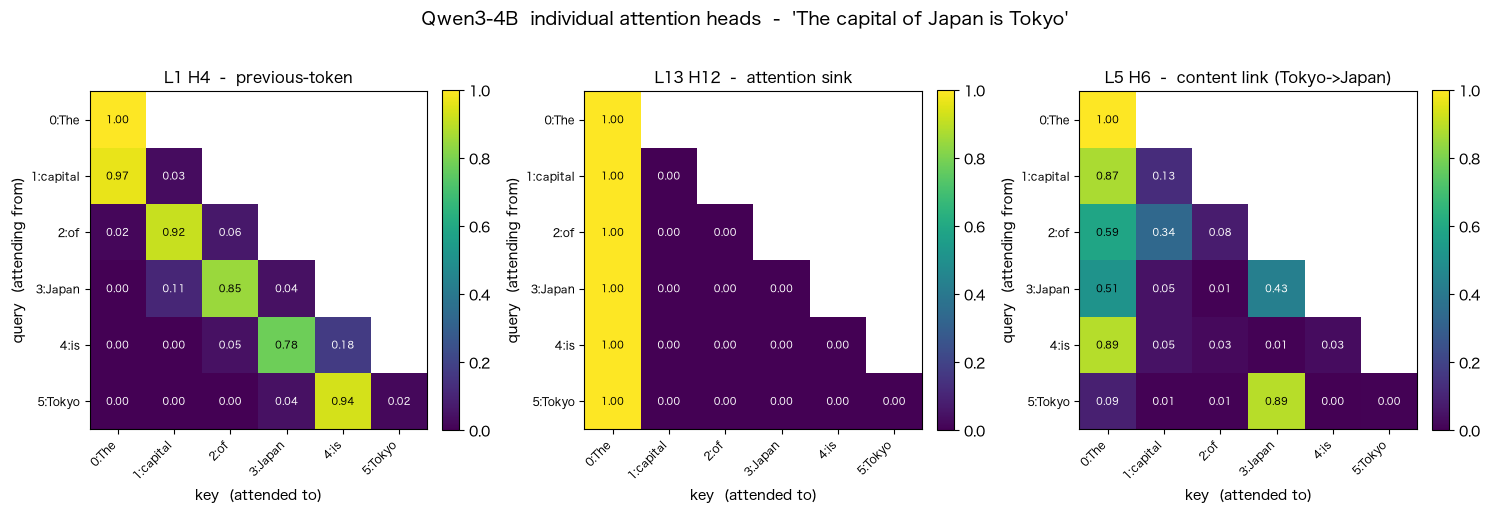

In [34]:
# 例文を forward して attention を取り出し（後続セルでも再利用）、役割の違う個別 head を並べる。
import numpy as np
import matplotlib.pyplot as plt

ATTN_PROMPT = "The capital of Japan is Tokyo"
attn_inputs = tokenizer(ATTN_PROMPT, return_tensors="pt").to(device)
attn_ids    = attn_inputs["input_ids"][0].tolist()
attn_pieces = [tokenizer.decode([t]) for t in attn_ids]
attn_labels = [f"{i}:{p.strip()}" for i, p in enumerate(attn_pieces)]
T = len(attn_ids)

attn_out = model(**attn_inputs, output_attentions=True, use_cache=False)
attentions = attn_out.attentions          # tuple 長さ K, 各 [1, n_heads, T, T]
n_heads = attentions[0].shape[1]
A = np.stack([a[0].float().cpu().numpy() for a in attentions], axis=0)  # [K, n_heads, T, T]
print(f"tokens: {attn_pieces}")
print(f"K={K} layers, n_heads={n_heads}, T={T}")

# 役割の違う個別 head を名指しで選ぶ： (layer, head, 説明)
PICKS = [
    (1, 4,   "L1 H4  -  previous-token"),
    (13, 12, "L13 H12  -  attention sink"),
    (5, 6,   "L5 H6  -  content link (Tokyo->Japan)"),
]
tri = np.triu(np.ones((T, T)), 1) > 0     # 上三角(未来) = causal mask

fig, axes = plt.subplots(1, len(PICKS), figsize=(5.0 * len(PICKS), 5.0))
for ax, (L, h, title) in zip(axes, PICKS):
    M = np.ma.masked_where(tri, A[L, h])                     # 未来をマスク
    im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1, aspect="equal")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("key  (attended to)")
    ax.set_ylabel("query  (attending from)")
    ax.set_xticks(range(T)); ax.set_xticklabels(attn_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels(attn_labels, fontsize=8)
    for i in range(T):
        for j in range(i + 1):
            v = A[L, h, i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Qwen3-4B  individual attention heads  -  {ATTN_PROMPT!r}", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(outputs_dir / "nb02_attention_individual_heads.png", dpi=200)
plt.show()


### 全 head を一望する：平均からの差分で個性を見る

Qwen3-4B は 1 layer あたり 32 head、全 36 layer で **1152 個**の self-attention matrix (SAM) を持つ。
そのまま並べるとどれも「causal な下三角」に見えて個性が埋もれる（共通成分＝三角形の形と
attention sink が支配的だから）。そこで **各位置 $(q,k)$ の全体平均を引いた差分**を見る:

$$
D^{(\ell)}_h[q,k] \;=\; A^{(\ell)}_h[q,k] \;-\; \frac{1}{K H}\sum_{\ell',h'} A^{(\ell')}_{h'}[q,k]
$$

赤 = 平均より強く見ている ($+$)、青 = 弱い ($-$)、白 = 平均通り。共通成分がキャンセルされ、
各 head **固有**の注目パターンだけが残る。

**head の番号自体に固定した意味はない**（学習の中で各 head の役割は分かれていくが、番号の付き方は任意）。
そこで各 layer 行の中で、head を **差分の下三角ベクトルの L2 ノルム** $\lVert D^{(\ell)}_h \rVert$ で
並べ替える（layer をまたぐ固定の並びには意味がないので、**行ごとに独立**にソートする）:

- 横方向: 各行で 左 = 個性的（平均から遠い）→ 右 = 平均的（$D\approx0$、白）
- 縦方向: 下 = 入力層 (0) → 上 = 出力層 (35)

読み取れること:
- 多くのセルに現れる**赤い副対角** = 「直前の token を平均より強く見る」previous-token head。
- 下（入力層）ほど個性的な head が多く、上（出力層）は白っぽい＝平均的な attention に寄る。
- 注意: これは *どこを見ているか*（attention weight）の図であって、*出力にどれだけ効くか*（因果的
  重要度）ではない。両者は一致しないことが多い（後者は activation patching で測る、§11-15 参照）。


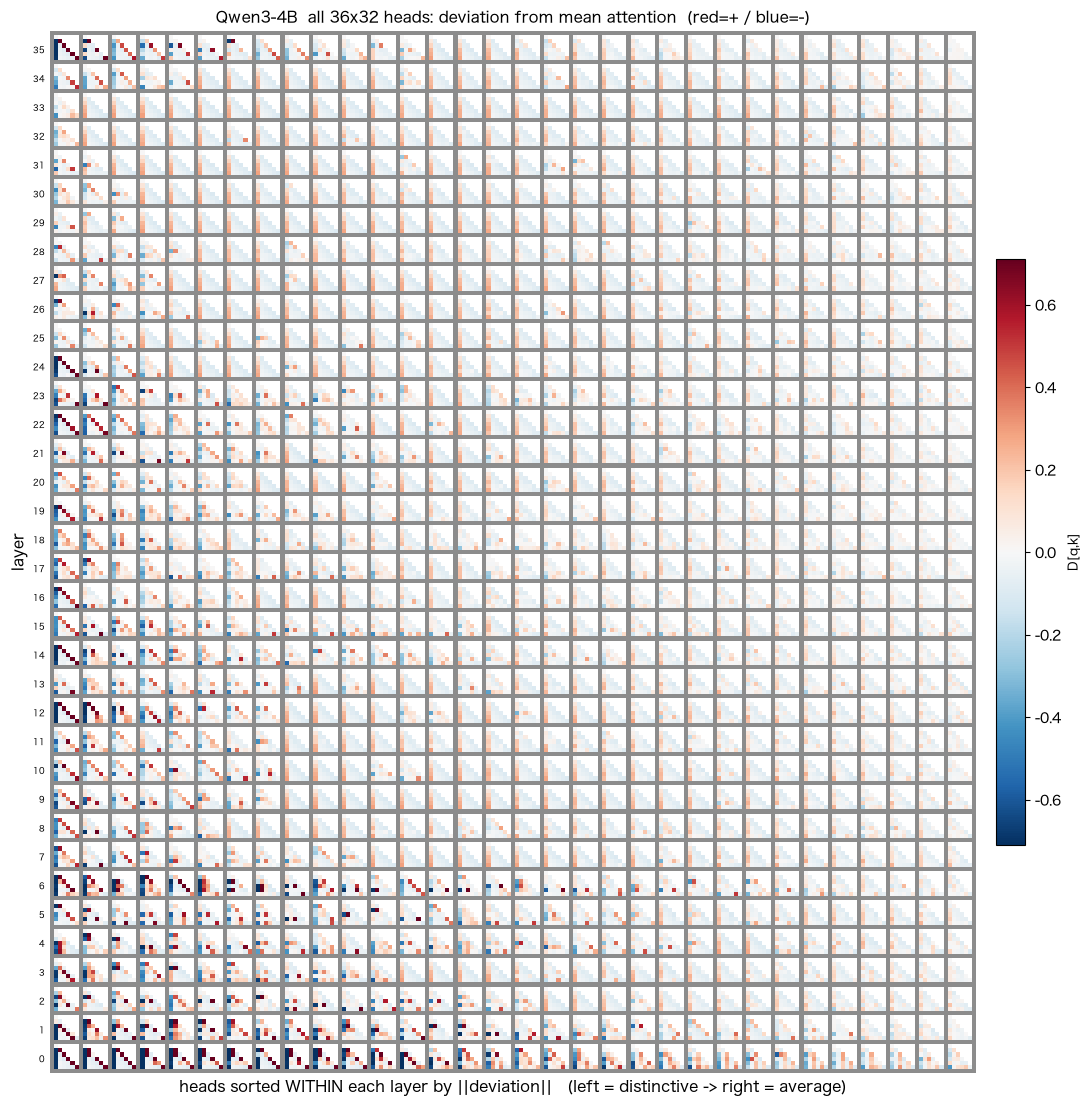

In [35]:
# 全 layer x 全 head の SAM を「全体平均からの差分」で一枚に敷き詰める。
# 直前のセルで計算した attentions / n_heads / T を再利用する。
import numpy as np
import matplotlib.pyplot as plt

A = np.stack([a[0].float().cpu().numpy() for a in attentions], axis=0)  # [K, n_heads, T, T]

tri_mask = np.triu(np.ones((T, T)), k=1) > 0     # 上三角(未来) = causal mask
low_mask = ~tri_mask                              # 下三角+対角 = 有効セル

baseline = A.mean(axis=(0, 1))                    # [T,T] 各位置 (q,k) の全体平均
D = A - baseline[None, None]                      # [K, n_heads, T, T] 差分

# color スケール: 下三角の有効セルの |D| 99 パーセンタイルで対称に
vmax = float(np.percentile(np.abs(D[:, :, low_mask]), 99))
cmap = plt.get_cmap("RdBu_r")                     # + = 赤, - = 青, 0 = 白
cnorm = plt.Normalize(vmin=-vmax, vmax=vmax)
GAP_RGB, BAD_RGB = (0.55, 0.55, 0.55), (1.0, 1.0, 1.0)  # セル境界=灰 / 未来セル=白

# 各 layer 行の中で ||D|| の大きい head を左へ（行ごと独立ソート = 添字を捨てる）
normD_LH = np.linalg.norm(D[:, :, low_mask], axis=2)   # [K, n_heads]

cell, g = T, 1
canvasH = K * (cell + g) + g
canvasW = n_heads * (cell + g) + g
rgb = np.full((canvasH, canvasW, 3), GAP_RGB, dtype=float)
for r in range(K):
    L = (K - 1) - r                               # 上 = 出力層
    row_order = np.argsort(-normD_LH[L])          # 個性的(ノルム大) -> 左
    for c, head in enumerate(row_order):
        colored = cmap(cnorm(D[L, head]))[..., :3]
        colored[tri_mask] = BAD_RGB
        y0, x0 = g + r * (cell + g), g + c * (cell + g)
        rgb[y0:y0 + cell, x0:x0 + cell] = colored

fig, ax = plt.subplots(figsize=(11, 12))
ax.imshow(rgb, interpolation="nearest", aspect="equal")
ax.set_xticks([])
layer_centers = [g + ((K - 1) - L) * (cell + g) + cell / 2 for L in range(K)]
ax.set_yticks(layer_centers)
ax.set_yticklabels([str(L) for L in range(K)], fontsize=6)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xlabel("heads sorted WITHIN each layer by ||deviation||   (left = distinctive -> right = average)",
              fontsize=11)
ax.set_ylabel(f"layer", fontsize=11)
ax.set_title(f"Qwen3-4B  all {K}x{n_heads} heads: deviation from mean attention  (red=+ / blue=-)",
             fontsize=11)
sm = plt.cm.ScalarMappable(norm=cnorm, cmap=cmap)
fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02).set_label("D[q,k]", fontsize=9)
fig.tight_layout()
fig.savefig(outputs_dir / "nb02_attention_head_mosaic.png", dpi=200)
plt.show()


### 帯を定量化：層ごとの attention 個性度

モザイクで見えた「L22-24 の帯」を折れ線にする。各 layer について head 方向に $\|D\|$ を集計する
（$\|D\|$ = 差分の下三角ベクトルの L2 ノルム）:

- $\max_h \|D\|$（赤）= その層で最も個性的な 1 head
- $\mathrm{mean}_h \|D\|$（青）= 全 head 平均

$\max_h\|D\|$ は L22・L24 で山を作り **L25 で急落**する。個性的な attention は L24 あたりまでで一段落し、
深層はほぼ平均に近づく**ように見える** — これは activation patching（§11-15）が「$\text{Tokyo}$ の決定は L24 付近で
完了」と示したことと整合的。一方 $\mathrm{mean}_h\|D\|$（青）は単調減衰で帯が出ない：帯は少数 head が
担う *few-heads* 現象なので、head 平均では薄まって消える（見せるには head 方向を $\max$ で取る必要がある）。

注意: これは *どこを見ているか*（attention weight）の相関であって、*出力への効き*（因果）ではない。
L24 の帯のどの head が実際に効くかは、その head を個別に activation patching して確かめる必要がある。


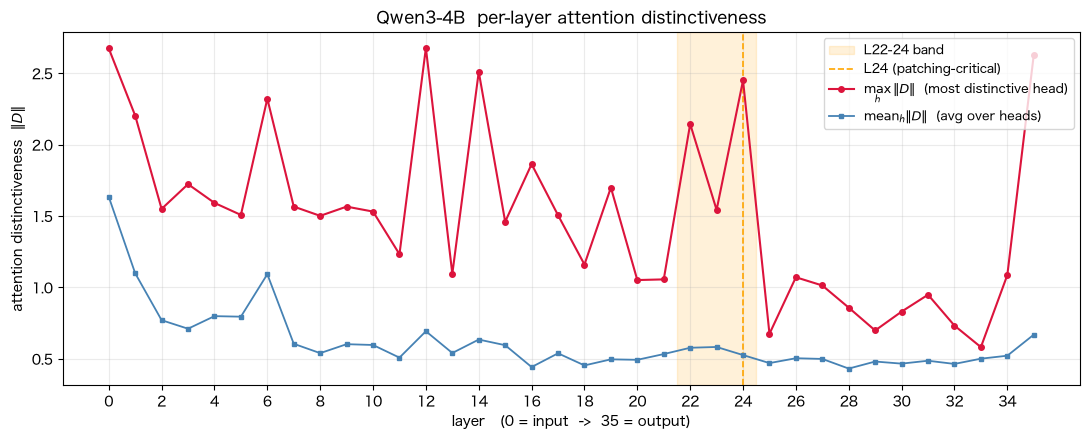

In [36]:
# 層ごとの attention 個性度を折れ線で。直前のセルの D / low_mask / K を再利用。
normD = np.linalg.norm(D[:, :, low_mask], axis=2)   # [K, n_heads]  各 (layer,head) の ||D||
mean_d = normD.mean(1)                               # head 平均
max_d = normD.max(1)                                 # head 方向 max (最も個性的な head)
layers = np.arange(K)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(21.5, 24.5, color="orange", alpha=0.15, label="L22-24 band")
ax.axvline(24, color="orange", ls="--", lw=1.2, label="L24 (patching-critical)")
ax.plot(layers, max_d, "o-", color="crimson", ms=4, lw=1.5,
        label=r"$\max_h\|D\|$  (most distinctive head)")
ax.plot(layers, mean_d, "s-", color="steelblue", ms=3, lw=1.3,
        label=r"$\mathrm{mean}_h\|D\|$  (avg over heads)")
ax.set_xlabel("layer   (0 = input  ->  35 = output)")
ax.set_ylabel(r"attention distinctiveness  $\|D\|$")
ax.set_title("Qwen3-4B  per-layer attention distinctiveness")
ax.set_xticks(range(0, K, 2))
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(outputs_dir / "nb02_attention_distinctiveness.png", dpi=200)
plt.show()


## 11. Activation Patching の概念と実装

### 概念

Activation Patching（残差ストリームパッチ）の手順：

1. **clean run** を実行 → 各 layer の hidden state `clean_hs[k]` を記録
2. **corrupt run** に hook を設置：layer $k$ の出力のうち `corrupt_pos` 位置だけを、`clean_hs[k][0, clean_pos, :]` で上書き
3. corrupt run を再実行 → 最終 logits を記録
4. **回復率 (recovery)** を計算

直感的には、「clean run のある層の活性を corrupt run に注入したとき、最終出力がどれだけ clean 側に戻るか」を層ごとに測ります。  
この回復の度合いを表す指標として **$\text{recovery}(k)$** を後で定義しますが、先取りして直感を述べると次のようになります。

- $\text{recovery}(k) \approx 0$ → layer $k$ のパッチは効果なし
- $\text{recovery}(k) \approx 1$ → layer $k$ のパッチで clean run に完全回復


### activation patching を設定するコード

以下に実装の核となる `run_patch(k)` を示す。詳細は後の数式定式化セクションで補足する。

In [37]:
def run_patch(k: int) -> torch.Tensor:
    """
    corrupt run の層 k 出力 (corrupt_hs[k][0, corrupt_pos, :]) を
    clean  run の層 k 出力 (clean_hs[k][0,  clean_pos, :])  で置換して
    最終 logits [vocab] を返す。

    Transformers 5.x: Qwen3DecoderLayer.forward() は tensor を直接返す（tuple でない）。
    hook は out.clone() してから置換し、tensor を return する。
    """
    # clean run の層 k における clean_pos の残差ストリームを取り出す
    patch_vec = clean_hs[k][0, clean_pos, :].to(device)

    # patch する対象モジュールを k に応じて選ぶ
    #   k == 0       : embed_tokens（埋め込み層の出力）
    #   1 <= k <= K-1: layers[k-1]（第 k-1 デコーダ層の出力）
    #   k == K       : norm（最終 LayerNorm の出力）
    if k == 0:
        target_module = model.model.embed_tokens
    elif k < K:
        target_module = model.model.layers[k - 1]
    else:
        target_module = model.model.norm

    # forward hook: target_module の出力が計算されるたびに呼ばれる
    #   out[0, corrupt_pos, :] だけを patch_vec で上書きし、残りはそのまま返す
    def hook(module, inp, out):
        out = out.clone()                        # 元テンソルを破壊しないようコピー
        out[0, corrupt_pos, :] = patch_vec       # 指定位置だけ置換
        return out                               # 後続の層はこの値を受け取る

    # hook を登録して corrupt run を再実行し、終了後に必ず hook を解除する
    handle = target_module.register_forward_hook(hook)
    try:
        patched_out = model(
            **corrupt_inputs,
            output_hidden_states=False,
            output_attentions=False,
            use_cache=False,
        )
    finally:
        handle.remove()   # 例外が起きても hook が残り続けないように

    # corrupt_pos における最終 logits を返す
    return patched_out.logits[0, corrupt_pos, :].float()

### 数式での定式化

**記号の準備**

以降、$k$ は **パッチをかけた layer index**（sweep 軸、$\text{recovery}(k)$ の $k$）を表します。  
residual stream の自由変数（現在見ている layer index）は $k'$（$0 \le k' \le K$）と書きます。

clean prompt と corrupt prompt それぞれに対する forward pass の residual stream を区別します。

- $h_t^{(k'),\text{clean}}$ は、clean run の hidden state
- $h_t^{(k'),\text{corrupt}}$ は、corrupt run の hidden state
- 注目する位置は、clean run では `clean_pos`、corrupt run では `corrupt_pos`（いずれも last position）

**Patching の操作**

layer $k$ にパッチをかけた状態の residual stream を $h_t^{(k'),\text{patched}(k)}$ と書きます。

- $k'=0,\ldots,k-1$では、corrupt run で forward します。つまり、$$h_t^{(k'),\text{patched}(k)} = h_t^{(k'),\text{corrupt}}$$

- $k'=k$では、**位置 $t=$ `corrupt_pos` だけ** clean run の対応する活性で上書き
  $$
  h_{\text{corrupt\_pos}}^{(k),\text{patched}(k)} := h_{\text{clean\_pos}}^{(k),\text{clean}}
  $$
します。その他の位置では、通常通り forward します。

- その後の、$k'=k+1,\ldots,K$では、通常通り forward します。

要するに、$k'=k$ の $t=$ `corrupt_pos` だけ、clean run の `clean_pos` で上書きし、それ以外は、通常どおり forward して得られる residual stream として定義します。

**最終 logits**

Section 7 の規約 ($h_t^{(K)}$ は post-norm) に従い、$W_U$ を作用させて最終 logits を得ます。

$$
z^{\text{clean}}      = W_U \, h_{\text{clean\_pos}}^{(K),\text{clean}}, \quad
z^{\text{corrupt}}    = W_U \, h_{\text{corrupt\_pos}}^{(K),\text{corrupt}}, \quad
z^{\text{patched}(k)} = W_U \, h_{\text{corrupt\_pos}}^{(K),\text{patched}(k)}
$$

**Logit-difference metric**

clean 側の答え token（` Tokyo`、`CLEAN_ANS_ID`）と corrupt 側の答え token（` Paris`、`CORRUPT_ANS_ID`）の logit 差を metric とします。

$$
m(z) = z_{\text{CLEAN\_ANS\_ID}} - z_{\text{CORRUPT\_ANS\_ID}}
$$

値が大きいほど clean 側の答えが優勢です。3 種類の metric を考えます。

$$
m^{\text{clean}}      = m(z^{\text{clean}}), \quad
m^{\text{corrupt}}    = m(z^{\text{corrupt}}), \quad
m^{\text{patched}(k)} = m(z^{\text{patched}(k)})
$$

$m^{\text{clean}}$ が recovery の上限、$m^{\text{corrupt}}$ がパッチなしの下限です。

**Recovery**

$$
\text{recovery}(k)
= \frac{m^{\text{patched}(k)} - m^{\text{corrupt}}}
       {m^{\text{clean}} - m^{\text{corrupt}}}
$$

- $\text{recovery}(k) \approx 0$ ⇒ layer $k$ のパッチは効果なし（corrupt のまま）
- $\text{recovery}(k) \approx 1$ ⇒ layer $k$ のパッチで clean に完全回復

### hidden_states インデックスと patch site の対応

patching を行う層 $k$ は、Section 7 で見た `hidden_states[k]`（= $h_t^{(k)}$）のインデックスとそのまま対応します。

| $k$ | patch site | 対応するモジュール |
|---|---|---|
| $k = 0$ | embed_tokens の出力 | `model.model.embed_tokens` |
| $1 \le k \le K-1$ | layers[$k-1$] の出力 | `model.model.layers[k-1]` |
| $k = K$ | final RMSNorm の出力 | `model.model.norm` |

実装上は、対応するモジュールの forward hook で、出力テンソルの `[0, corrupt_pos, :]` を `patch_vec` (= `clean_hs[k][0, clean_pos, :]`) に置換します。


### 概念図

下のセルで、clean run / corrupt run / patched run の 3 経路を 1 枚の図にまとめます。  
layer $k$（図中の `L_k`）の位置で、clean run の活性が patched run に注入される様子を示しています。


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


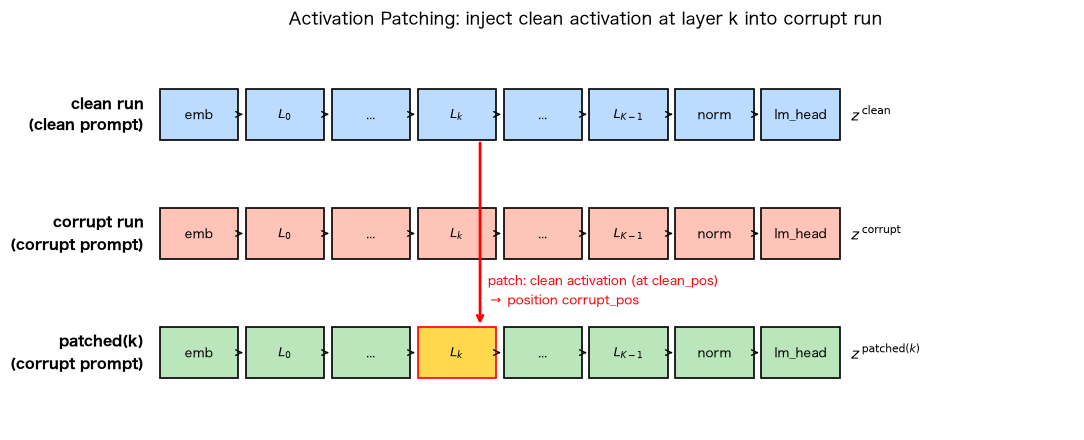

In [38]:
# Activation Patching の概念図 (schematic)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 4.5))

stages = ["emb", r"$L_0$", "...", r"$L_k$", "...", r"$L_{K-1}$", "norm", "lm_head"]
n = len(stages)
box_w, box_h = 0.10, 0.13
xs = [0.08 + i * 0.11 for i in range(n)]

# (label, y, color, output_text); label は改行で 2 行表記
rows = [
    ("clean run\n(clean prompt)",       0.73, "#bcdcff", r"$z^{\,\mathrm{clean}}$"),
    ("corrupt run\n(corrupt prompt)",   0.43, "#ffc4b8", r"$z^{\,\mathrm{corrupt}}$"),
    ("patched(k)\n(corrupt prompt)",    0.13, "#bbe6bb", r"$z^{\,\mathrm{patched}(k)}$"),
]

for label, y, color, output_text in rows:
    ax.text(0.06, y + box_h/2, label,
            ha="right", va="center", fontsize=10, fontweight="bold")
    for x, stage in zip(xs, stages):
        if label.startswith("patched") and stage == r"$L_k$":
            face = "#ffd84d"  # 注入された箱は強調
            ec = "red"
        else:
            face = color
            ec  = "black"
        ax.add_patch(mpatches.Rectangle((x, y), box_w, box_h,
                                        facecolor=face, edgecolor=ec, linewidth=1.2))
        ax.text(x + box_w/2, y + box_h/2, stage,
                ha="center", va="center", fontsize=9)
    for i in range(n - 1):
        ax.annotate("", xy=(xs[i+1], y + box_h/2),
                    xytext=(xs[i] + box_w, y + box_h/2),
                    arrowprops=dict(arrowstyle="->"))
    ax.text(xs[-1] + box_w + 0.015, y + box_h/2, output_text,
            ha="left", va="center", fontsize=11)

# clean L_k -> patched L_k の縦矢印
# 箱と重ならないよう、L_k 右端の外側に少しオフセット
k_idx = stages.index(r"$L_k$")
x_arrow = xs[k_idx] + box_w - 0.02
ax.annotate("",
            xy=(x_arrow, rows[2][1] + box_h),   # 矢頭: patched L_k 上端
            xytext=(x_arrow, rows[0][1]),       # 矢尾: clean L_k 下端
            arrowprops=dict(arrowstyle="->", color="red", lw=2.0))

# 注記 (2 行)、patched 行の上に配置して箱と重ならないようにする
ax.text(x_arrow + 0.010, rows[2][1] + box_h + 0.04,
        "patch: clean activation (at clean_pos)\n"
        r"$\rightarrow$ position corrupt_pos",
        ha="left", va="bottom", fontsize=9, color="red")

ax.set_xlim(0, 1.25)
ax.set_ylim(0, 1.0)
ax.axis("off")
ax.set_title("Activation Patching: inject clean activation at layer k into corrupt run",
             fontsize=12)
plt.tight_layout()
fig.savefig(outputs_dir / "nb02_patching_schematic.png", dpi=200)
plt.show()


## 12. 補足：forward hook の仕組みと挿入場所

> **読み飛ばし可**：このセクションは、PyTorch の forward hook 機構と Transformers の実装に踏み込む補足です。Section 11 の `run_patch` と activation patching の結果を理解するだけなら、読み飛ばしてかまいません。なお、ここでの記述は内部実装に関する説明を含み、不正確な箇所が含まれている可能性があります。活性パッチングの本筋（Section 11 まで）と分けて扱い、誤りに気づいた場合は PyTorch / Transformers の公式ドキュメントやソースを優先してください。

`run_patch(k)` は内部で **forward hook** という PyTorch の仕組みを使い、ある module の `forward` が返した出力テンソルに介入しています。このセクションでは、その仕組みを次の 4 段階に分けて確認します。

1. **PyTorch の forward hook とは何か**：登録した関数が `forward` の直後に自動で呼ばれる仕掛け
2. **Qwen3 モデルの中で patching の target になりうる 3 種類のモジュール**：`embed_tokens` / `layers[k-1]` / `norm`
3. **`Qwen3Model.forward` のソースで hook が発動する位置を特定する**：どの行で hook が発動（最近は「発火」とも呼ぶ）するか
4. **各 target_module の `forward` が tensor 1 つを返すことの確認**：これにより `out.clone()` で素直に書き換えられる


### PyTorch の forward hook とは何か

`module.register_forward_hook(fn)` を呼ぶと、`module._forward_hooks` という辞書に `fn` が登録されます。  
その後 `module(input)` を呼んで `forward()` が実行され、出力が確定した直後に PyTorch が `_forward_hooks` を順に呼び出します。各 hook は `fn(module, inputs, outputs)` の形で呼ばれ、戻り値を返せば PyTorch はその戻り値を新しい出力として後続層に渡します。これが、activation patching で `out.clone()` を書き換えた tensor を返すと、後続の層が **書き換え後の値を見る** ことができる理由です。

下の cell は、`nn.Module.register_forward_hook` のソースを表示しています。内部の `RemovableHandle` の dict 操作などの詳細は読み飛ばしてかまいません。


In [39]:
# register_forward_hook が何をするかを確認
# -> self._forward_hooks に hook 関数を登録する
# forward() が呼ばれるたびに _forward_hooks の中身が順番に実行される
import torch.nn as nn
print(inspect.getsource(nn.Module.register_forward_hook))

    def register_forward_hook(
        self,
        hook: Callable[[T, tuple[Any, ...], Any], Any | None]
        | Callable[[T, tuple[Any, ...], dict[str, Any], Any], Any | None],
        *,
        prepend: bool = False,
        with_kwargs: bool = False,
        always_call: bool = False,
    ) -> RemovableHandle:
        r"""Register a forward hook on the module.

        The hook will be called every time after :func:`forward` has computed an output.

        If ``with_kwargs`` is ``False`` or not specified, the input contains only
        the positional arguments given to the module. Keyword arguments won't be
        passed to the hooks and only to the ``forward``. The hook can modify the
        output. It can modify the input inplace but it will not have effect on
        forward since this is called after :func:`forward` is called. The hook
        should have the following signature::

            hook(module, args, output) -> None or modified output

        If ``with_kwar

### Qwen3 モデルの target_module 3 種類

Section 11 の表で見たとおり、`run_patch(k)` の hook は patching 層 $k$ に応じて、次の 3 つのモジュールのどれか 1 つに登録されます。

- `k == 0`：`model.model.embed_tokens` （入力 token を embedding に変換する `nn.Embedding`）
- `1 <= k <= K-1`：`model.model.layers[k-1]` （Qwen3 の decoder block、`Qwen3DecoderLayer`）
- `k == K`：`model.model.norm` （最終 RMSNorm、`Qwen3RMSNorm`）

下の 2 つの cell では、まず 3 種類のモジュールの **型** を確認し、続いて実際のモジュールの中身（部分構造）を取り出して確認します。`layers[1], layers[2], ...` も `layers[0]` と同じ構造なので、代表として `layers[0]` のみ表示します。


In [40]:
# run_patch で使う3種類の target_module の型を確認
print("embed_tokens:", type(model.model.embed_tokens))
print("layers[0]   :", type(model.model.layers[0]))
print("norm        :", type(model.model.norm))

embed_tokens: <class 'torch.nn.modules.sparse.Embedding'>
layers[0]   : <class 'transformers.models.qwen3.modeling_qwen3.Qwen3DecoderLayer'>
norm        : <class 'transformers.models.qwen3.modeling_qwen3.Qwen3RMSNorm'>


In [41]:
# patching の target になりうる 3 つのモジュールを実際に取り出して確認
print("=== model.model.embed_tokens ===")
print(model.model.embed_tokens)
print()
print("=== model.model.layers[0] === （layers[1..K-1] も同じ構造）")
print(model.model.layers[0])
print()
print("=== model.model.norm ===")
print(model.model.norm)


=== model.model.embed_tokens ===
Embedding(151936, 2560)

=== model.model.layers[0] === （layers[1..K-1] も同じ構造）
Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
    (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
    (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
    (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
    (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
    (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
)

=== model.model.norm ===
Qwen3RMSNorm((2560,), eps=1e-06)


### `Qwen3Model.forward` のソースで hook が発動する位置を確認する

Qwen3 モデルの本体である `Qwen3Model.forward` のソースを表示します。注目するのは次の 3 行です。

- `inputs_embeds = self.embed_tokens(input_ids)` ← `k == 0` の hook が発動する箇所
- `hidden_states = decoder_layer(hidden_states, ...)`（for ループの中） ← `1 <= k <= K-1` の hook が発動する箇所
- `hidden_states = self.norm(hidden_states)` ← `k == K` の hook が発動する箇所

それぞれの `forward` 呼び出しが `return` した **直後** に hook が発火します。


In [42]:
# Qwen3Model.forward — 計算順序を確認する
from transformers.models.qwen3.modeling_qwen3 import Qwen3Model
print(inspect.getsource(Qwen3Model.forward))

    @merge_with_config_defaults
    @capture_outputs
    @auto_docstring
    def forward(
        self,
        input_ids: torch.LongTensor | None = None,
        attention_mask: torch.Tensor | None = None,
        position_ids: torch.LongTensor | None = None,
        past_key_values: Cache | None = None,
        inputs_embeds: torch.FloatTensor | None = None,
        use_cache: bool | None = None,
        **kwargs: Unpack[TransformersKwargs],
    ) -> BaseModelOutputWithPast:
        if (input_ids is None) ^ (inputs_embeds is not None):
            raise ValueError("You must specify exactly one of input_ids or inputs_embeds")

        if inputs_embeds is None:
            inputs_embeds = self.embed_tokens(input_ids)

        if use_cache and past_key_values is None:
            past_key_values = DynamicCache(config=self.config)

        if position_ids is None:
            past_seen_tokens = past_key_values.get_seq_length() if past_key_values is not None else 0
            position_id

上記の `Qwen3Model.forward` のソースに対応する `run_patch(k)` の hook 登録先を表にまとめます。

| `k` | `Qwen3Model.forward` 内の該当行 | `target_module` |
|---|---|---|
| `k == 0` | `inputs_embeds = self.embed_tokens(input_ids)` | `model.model.embed_tokens` |
| `1 <= k <= K-1` | `hidden_states = decoder_layer(hidden_states, ...)`（for ループの $k' = k$ 回目、つまり出力が `hs[k]` になる回。`self.layers[k-1]` が適用される） | `model.model.layers[k-1]` |
| `k == K` | `hidden_states = self.norm(hidden_states)` | `model.model.norm` |

該当モジュールの `forward` が `return` した直後に hook 関数が呼ばれ、出力テンソルの `[0, corrupt_pos, :]` だけを `patch_vec` で置換します。


### 各 target_module の `forward` が tensor 1 つを返すことの確認

`run_patch` の hook 関数は、

```python
def hook(module, inp, out):
    out = out.clone()
    out[0, corrupt_pos, :] = patch_vec
    return out
```

のように `out` をそのまま tensor として扱い、`out[0, corrupt_pos, :] = ...` で 1 行だけ書き換えています。これが成立するのは、3 種類の target_module（`Qwen3DecoderLayer`、`nn.Embedding`、`Qwen3RMSNorm`）の `forward` が、いずれも **tuple ではなく単一の tensor** を返すからです。返り値が tuple なら、`out[0]` を取り出してから書き換える等の処理が必要になります。

以降の cell で、それぞれのモジュールの `forward` を確認します。まずは `Qwen3DecoderLayer.forward` の骨格を疑似コード化したものを示します。


```
residual = hidden_states
hidden_states = self.input_layernorm(hidden_states)
hidden_states = self.self_attn(...)          # Attention
hidden_states = residual + hidden_states     # 残差結合 (1)

residual = hidden_states
hidden_states = self.post_attention_layernorm(hidden_states)
hidden_states = self.mlp(hidden_states)      # MLP
hidden_states = residual + hidden_states     # 残差結合 (2)

return hidden_states   # ← hook はこの return の直後に呼ばれる
```

返り値が tuple でなく **tensor 1 つ** であることが見えます。これが、`out.clone()` で出力テンソルを直接書き換えられる理由です。下の cell に実際のソースを表示します。


In [43]:
# decoder layer の forward を確認
# Qwen3DecoderLayer.forward（k=1..K-1 のとき）
from transformers.models.qwen3.modeling_qwen3 import Qwen3DecoderLayer, Qwen3RMSNorm
print(inspect.getsource(Qwen3DecoderLayer.forward))

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        position_ids: torch.LongTensor | None = None,
        past_key_values: Cache | None = None,
        use_cache: bool | None = False,
        position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
        **kwargs: Unpack[TransformersKwargs],
    ) -> torch.Tensor:
        residual = hidden_states
        hidden_states = self.input_layernorm(hidden_states)
        # Self Attention
        hidden_states, _ = self.self_attn(
            hidden_states=hidden_states,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            use_cache=use_cache,
            position_embeddings=position_embeddings,
            **kwargs,
        )
        hidden_states = residual + hidden_states

        # Fully Connected
        residual = hidden_states
        hidden_states = self.post_att

次に `k == 0` のときの target である `nn.Embedding.forward` を確認します。これも返り値は単一の tensor です。


In [44]:
# nn.Embedding.forward（k=0 のとき）
import torch.nn as nn
print(inspect.getsource(nn.Embedding.forward))

    def forward(self, input: Tensor) -> Tensor:
        return F.embedding(
            input,
            self.weight,
            self.padding_idx,
            self.max_norm,
            self.norm_type,
            self.scale_grad_by_freq,
            self.sparse,
        )



最後に `k == K` のときの target である `Qwen3RMSNorm.forward` を確認します。こちらも単一の tensor を返します。


In [45]:
# Qwen3RMSNorm.forward（k=K のとき）
print(inspect.getsource(Qwen3RMSNorm.forward))

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)



## 13. 全 layer スイープ

**数式記号と Python 変数の対応**

| 数式 | Python | 内容 |
|---|---|---|
| $z^{\text{clean}}$ | `clean_logits` | clean run の最終 logits |
| $z^{\text{corrupt}}$ | `corrupt_logits` | corrupt run の最終 logits |
| $z^{\text{patched}(k)}$ | `plogits`（`run_patch(k)` の戻り値） | layer $k$ をパッチした後の最終 logits |
| $m^{\text{clean}}$ | `clean_metric` | $m(z^{\text{clean}})$ |
| $m^{\text{corrupt}}$ | `corrupt_metric` | $m(z^{\text{corrupt}})$ |
| $m^{\text{patched}(k)}$ | `pm`（sweep loop 内） | $m(z^{\text{patched}(k)})$ |
| $\mathrm{recovery}(k)$ | `rec` | 上式どおり |

`metric(logits, clean_id, corrupt_id)`（前セルで定義） がこの $m(z) = z_{\text{clean\_id}} - z_{\text{corrupt\_id}}$ に対応します。


In [46]:
# metric のベースライン（recovery 計算の分母）
clean_metric   = metric(clean_logits,   CLEAN_ANS_ID, CORRUPT_ANS_ID)
corrupt_metric = metric(corrupt_logits, CLEAN_ANS_ID, CORRUPT_ANS_ID)
print(f"clean   metric = {clean_metric:.4f}")
print(f"corrupt metric = {corrupt_metric:.4f}")

# patching sweep
sweep_rows = []
print(f"Patching sweep: k = 0 ... {K}")
for k in range(K + 1):
    plogits = run_patch(k)
    pprobs = torch.softmax(plogits, dim=-1)
    pm  = metric(plogits, CLEAN_ANS_ID, CORRUPT_ANS_ID)
    rec = (pm - corrupt_metric) / (clean_metric - corrupt_metric)
    site = "embed" if k == 0 else (f"L{k-1:02d}" if k < K else "norm")
    sweep_rows.append({
        "k": k,
        "site": site,
        "p_clean_patched": pprobs[CLEAN_ANS_ID].item(),
        "p_corrupt_patched": pprobs[CORRUPT_ANS_ID].item(),
        "patched_metric": pm,
        "recovery": rec,
    })
    if k % 5 == 0 or k == K:
        print(f"  k={k:2d} ({site:6s}): recovery={rec:.4f}")

df_sweep = pd.DataFrame(sweep_rows)
out = outputs_dir / "nb02_patching_sweep.csv"
df_sweep.to_csv(out, index=False)
print(f"Saved: {out.name}")

display(df_sweep.set_index("k").style.set_caption("patching sweep").format({"recovery": "{:.4f}", "patched_metric": "{:.4f}", "p_clean_patched": "{:.4f}", "p_corrupt_patched": "{:.4f}"}))

clean   metric = 11.6953
corrupt metric = -11.9844
Patching sweep: k = 0 ... 36
  k= 0 (embed ): recovery=0.0000


  k= 5 (L04   ): recovery=0.0023
  k=10 (L09   ): recovery=-0.0541


  k=15 (L14   ): recovery=-0.0284
  k=20 (L19   ): recovery=-0.0125


  k=25 (L24   ): recovery=0.6308
  k=30 (L29   ): recovery=0.7757


  k=35 (L34   ): recovery=0.9951
  k=36 (norm  ): recovery=1.0000
Saved: nb02_patching_sweep.csv


,site,p_clean_patched,p_corrupt_patched,patched_metric,recovery
k,,,,,
0,embed,0.0000,0.6346,-11.9844,0.0000
1,L00,0.0000,0.6474,-11.9531,0.0013
2,L01,0.0000,0.6462,-11.9375,0.0020
3,L02,0.0000,0.6671,-12.0391,-0.0023
4,L03,0.0000,0.6610,-11.9688,0.0007
5,L04,0.0000,0.6680,-11.9297,0.0023
6,L05,0.0000,0.6853,-12.0156,-0.0013
7,L06,0.0000,0.7736,-11.6641,0.0135
8,L07,0.0000,0.8470,-11.8281,0.0066


### パッチ注入後の P(answer)

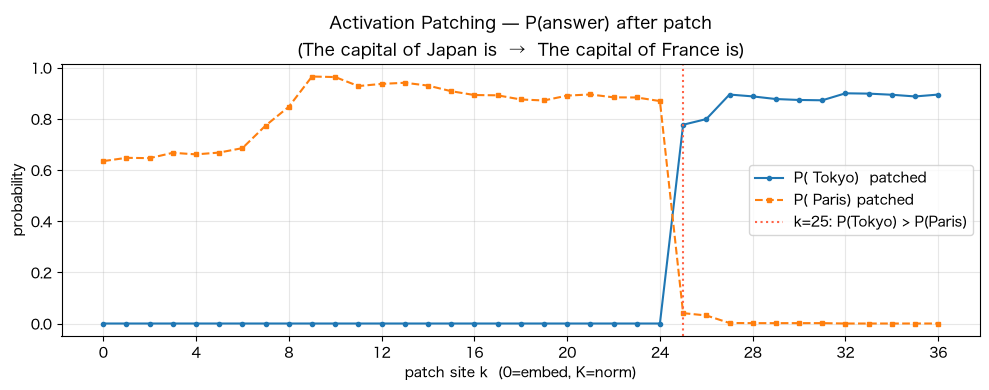

Saved: nb02_patching_probs.png
最初に 確率が入れ替わる layer: k=25


In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sweep["k"], df_sweep["p_clean_patched"],   label=f"P({CLEAN_ANSWER})  patched", marker="o", markersize=3)
ax.plot(df_sweep["k"], df_sweep["p_corrupt_patched"], label=f"P({CORRUPT_ANSWER}) patched", marker="s", markersize=3, linestyle="--")
ax.set_xlabel("patch site k  (0=embed, K=norm)")
ax.set_ylabel("probability")
ax.set_title(f"Activation Patching — P(answer) after patch\n({CLEAN_PROMPT}  →  {CORRUPT_PROMPT})")
ax.legend()
ax.set_xticks(range(0, K + 1, 4))
ax.grid(True, alpha=0.3)

# p_clean_patched が p_corrupt_patched を初めて上回る k に赤線を引く
cross = df_sweep[df_sweep["p_clean_patched"] > df_sweep["p_corrupt_patched"]]
if len(cross) > 0:
    k_cross = int(cross["k"].min())  # pyright: ignore[reportArgumentType]
    ax.axvline(k_cross, color="tomato", linestyle=":", linewidth=1.5,
               label=f"k={k_cross}: P({CLEAN_ANSWER.strip()}) > P({CORRUPT_ANSWER.strip()})")
    ax.legend()

plt.tight_layout()
out = outputs_dir / "nb02_patching_probs.png"
plt.savefig(out, dpi=300)
plt.show()
print(f"Saved: {out.name}")
if len(cross) > 0:
    print(f"最初に 確率が入れ替わる layer: k={k_cross}")

### Recovery curve

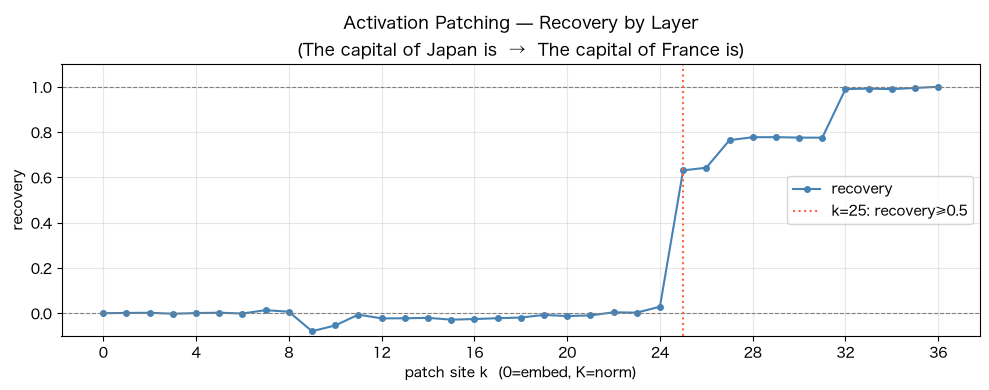

Saved: nb02_recovery_curve.png
最初に recovery≥0.5 になる layer: k=25


In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sweep["k"], df_sweep["recovery"], marker="o", markersize=4, color="steelblue", label="recovery")
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("patch site k  (0=embed, K=norm)")
ax.set_ylabel("recovery")
ax.set_title(f"Activation Patching — Recovery by Layer\n({CLEAN_PROMPT}  →  {CORRUPT_PROMPT})")
ax.set_xticks(range(0, K + 1, 4))
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

# 最初に recovery >= 0.5 になる k にマーカー
transition = df_sweep.loc[df_sweep["recovery"] >= 0.5, "k"]
if len(transition) > 0:
    k_transition = int(transition.min())
    ax.axvline(k_transition, color="tomato", linestyle=":", linewidth=1.5,
               label=f"k={k_transition}: recovery≥0.5")
    ax.legend()

plt.tight_layout()
out = outputs_dir / "nb02_recovery_curve.png"
plt.savefig(out, dpi=300)
plt.show()
print(f"Saved: {out.name}")
if len(transition) > 0:
    print(f"最初に recovery≥0.5 になる layer: k={k_transition}")


### 補足：Logit Lens と Activation Patching の比較

logit-difference metric で見ると、Logit Lens でも Activation Patching でも k=25 付近が転換点として現れる。
両手法は異なる操作だが、この題材では**同じ層を重要と示している**。

| 操作 | 内容 |
|------|------|
| **Logit Lens** | 層 k の残差ストリームを**その場で** lm_head（+norm）に通して読む |
| **Activation Patching** | 層 k の残差ストリームを差し替えたあと、**残りの層を通常通り forward** させる |

ただし、Activation Patching の recovery curve の方が変化がクリアに見える。
Logit Lens は「その時点の表現を直接読む」ため、後続の層による変換が反映されない。
Activation Patching は残りの層を通してから評価するため、残差ストリームの「影響力」をより直接的に測れる。

なお、確率（softmax）で見ると k=25 での変化は小さく見えるが、これは確率が後半層で急峻に飽和するためであり、
logit-difference metric を使うことで前半・中盤の変化が正確に読み取れる。

## 14. 特定 layer のパッチ後 top-k 比較

In [49]:
# 特定 layer のパッチ後 logits を計算
plogits_24 = run_patch(24)
plogits_25 = run_patch(25)
plogits_K  = run_patch(K)

labels = [
    ("clean baseline",   clean_logits),
    ("corrupt baseline", corrupt_logits),
    ("patch k=24",       plogits_24),
    ("patch k=25",       plogits_25),
    (f"patch k=K={K}",   plogits_K),
]

for label, lgts in labels:
    rec_val = (metric(lgts, CLEAN_ANS_ID, CORRUPT_ANS_ID) - corrupt_metric) / (clean_metric - corrupt_metric)
    display(topk_table(lgts, k=5).style.set_caption(f"{label}  (recovery={rec_val:.4f})"))

# k=K サニティチェック: recovery=1.000 になるはず
recK = (metric(plogits_K, CLEAN_ANS_ID, CORRUPT_ANS_ID) - corrupt_metric) / (clean_metric - corrupt_metric)
print(f"k=K sanity: recovery = {recK:.6f}  (expected 1.000)")
if abs(recK - 1.0) > 1e-3:
    print("[warning] recovery != 1.000  (hook の実装を確認)")

,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502


,token_id,decoded,logit,prob
rank,,,,
1,12095,' Paris',20.828125,0.634561
2,304,' in',20.015625,0.281585
3,7407,' located',18.046875,0.039318
4,264,' a',17.359375,0.019770
5,1304,' __',16.109375,0.005664


,token_id,decoded,logit,prob
rank,,,,
1,12095,' Paris',20.218750,0.869205
2,304,' in',16.343750,0.018040
3,1304,' __',16.328125,0.017760
4,7407,' located',16.000000,0.012792
5,32671,' ______',15.734375,0.009808


,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',20.031250,0.776653
2,12095,' Paris',17.078125,0.040523
3,1304,' __',17.031250,0.038667
4,7407,' located',16.703125,0.027851
5,304,' in',16.265625,0.017982


,token_id,decoded,logit,prob
rank,,,,
1,26194,' Tokyo',19.968750,0.894622
2,1304,' __',16.375000,0.024598
3,32671,' ______',15.507812,0.010334
4,304,' in',15.335938,0.008702
5,7407,' located',15.187500,0.007502


k=K sanity: recovery = 1.000000  (expected 1.000)


## 15. Activation Patching Grid：layer × position

ここでは、activation patching の結果を layer × position の grid として可視化します。

既存の recovery curve では、最後の position だけを patch し、layer 方向に sweep しました。ここでは、patch する position $p$ も動かします。評価はこれまでと同じく、最後の position における `logit(" Tokyo") - logit(" Paris")` の recovery で行います。

Section 11 の数式では patch 位置を `corrupt_pos`（最後の position）に固定していました。ここでは patch 位置 $p$ も sweep するため、patched run を $\text{patched}(k, p)$ と書き直します。$k' = k$ では、

$$
h_{p}^{(k),\text{patched}(k, p)} := h_{p}^{(k),\text{clean}}
$$

として、その他の位置・layer は通常通り forward します。今回は clean / corrupt prompt の長さが等しく、position ごとの対応が自然なので、両側で同じ $p$ を使います。recovery も $(k, p)$ で添字付けされます：

$$
\text{recovery}(k, p)
= \frac{m^{\text{patched}(k, p)} - m^{\text{corrupt}}}
       {m^{\text{clean}} - m^{\text{corrupt}}}
$$

ここで metric $m$ の評価は、Section 11 と同じく **常に最後の position の logits** に対して行います。$p$ は patch する位置であって、評価する位置ではないことに注意してください。既存の recovery curve は $p =$ `corrupt_pos` に固定した断面 $\text{recovery}(k, \text{corrupt\_pos})$ に対応します。

セル内の文字は、Section 8 の clean 側 logit lens grid と同じです。つまり、patch 後の最終出力ではなく、patch した clean hidden state を logit lens で読んだ top-1 token です。一方、色は logit lens grid とは異なり、その clean hidden state を corrupt run に patch したときの recovery を表します。つまり、この図では「logit lens ではどのように読める clean activation を差し込むと、最終出力がどれくらい Tokyo 側に戻るか」を見ています。

このセルは、layer と position の全組み合わせについて patching を行うため、約 (K+1) × T ≈ 185 回の forward を実行します。


### 1) `run_patch_at_position` の定義

Section 11 で定義した `run_patch(k)` は最後の position だけを patch する版でした。ここでは `patch_pos` も引数に取り、任意の (layer, position) を patch できるように一般化します。hook の登録先と置換ロジックは `run_patch(k)` と同じです。


In [50]:
# activation patching grid を計算するヘルパー関数
#
# Section 11 で定義した run_patch(k) は、最後の position だけを patch する版だった。
# ここでは patch_pos も引数に取り、任意の (layer, position) を patch できるよう一般化する。
# hook の登録先と置換ロジックは run_patch(k) と同じ。
def run_patch_at_position(k: int, patch_pos: int) -> torch.Tensor:
    """
    clean run の (層 k, 位置 patch_pos) の残差ストリームを取り出し、
    corrupt run の同じ (層 k, 位置 patch_pos) に patch して
    最後の position (corrupt_pos) の logits [vocab] を返す。

    既存の run_patch(k) は最終 position のみを patch する版で、
    こちらは patch_pos も動かせるように一般化したもの。
    """
    # clean side の (層 k, 位置 patch_pos) の hidden state を取り出す。
    # これを corrupt side の同じ場所に差し込む。
    patch_vec = clean_hs[k][0, patch_pos, :].to(device)

    # k に応じて hook を張る module を切り替える（run_patch(k) と同じ規約）。
    #   k == 0       : embed_tokens（埋め込み層の出力）
    #   1 <= k <= K-1: layers[k-1]（第 k-1 デコーダ層の出力）
    #   k == K       : norm（最終 LayerNorm の出力）
    if k == 0:
        target_module = model.model.embed_tokens
    elif k < K:
        target_module = model.model.layers[k - 1]
    else:
        target_module = model.model.norm

    def hook(module, inp, out):
        # 出力 tensor の patch_pos 行だけを clean side の値で置き換え、それ以外はそのまま。
        # Qwen3DecoderLayer / Embedding / RMSNorm はいずれも tensor を直接返すが、
        # 念のため tuple / list ケースにも対応しておく。
        if isinstance(out, tuple):
            first = out[0].clone()
            first[0, patch_pos, :] = patch_vec
            return (first,) + out[1:]
        if isinstance(out, list):
            first = out[0].clone()
            first[0, patch_pos, :] = patch_vec
            return [first] + list(out[1:])
        # 元 tensor を破壊しないよう clone してから書き換える。
        patched = out.clone()
        patched[0, patch_pos, :] = patch_vec
        return patched

    # hook を登録 → corrupt prompt で forward → 例外があっても必ず hook を解除。
    handle = target_module.register_forward_hook(hook)
    try:
        patched_out = model(
            **corrupt_inputs,
            output_hidden_states=False,  # grid 計算では中間 hidden は使わないのでメモリ節約
            output_attentions=False,
            use_cache=False,
        )
    finally:
        handle.remove()

    # 評価に使うのは「最後の position における next-token logits」のみ。
    # float32 で CPU に持ってきておくと、後段で numpy / 比較に使いやすい。
    return patched_out.logits[0, corrupt_pos, :].float().detach().cpu()


### 2) layer × position 全組合せで patching を実行

ここで実際に `(K+1) × T_grid` 個の forward を回し、3 種類の grid を埋めます。

- `recovery_grid[k, patch_pos]` — そのセルでの recovery（色になる）
- `text_grid[k][patch_pos]` — clean side の hidden state を logit lens で読んだ top-1 token（セル内文字になる）
- `patched_top1_is_clean[k, patch_pos]` — patch 後の最終 top-1 が `" Tokyo"` になったか（枠の有無になる）

各セルの生の値は `nb02_activation_patching_grid_recovery.csv` にも保存します。色や枠だけでは見えない数値情報を後で参照できるようにするためです。


In [51]:
# layer × position の全組合せで activation patching を実行し、3 種類の grid を埋める。
#   recovery_grid[k, p]         : 色になる（recovery の値）
#   text_grid[k][p]             : セル内文字（clean activation の logit lens top-1 token）
#   patched_top1_is_clean[k, p] : 枠の有無（patch 後の最終 top-1 が " Tokyo" か否か）
# このセルでは (K+1) × T_grid 回の forward を回すため、少し時間がかかる。

# clean / corrupt baseline metric（recovery 計算の分母として再計算）
# 上流のセルが部分実行された状況でもこのセル単体で動くよう、ここで baseline を取り直す。
_clean_metric_grid   = metric(clean_logits,   CLEAN_ANS_ID, CORRUPT_ANS_ID)
_corrupt_metric_grid = metric(corrupt_logits, CLEAN_ANS_ID, CORRUPT_ANS_ID)
_metric_range        = _clean_metric_grid - _corrupt_metric_grid  # recovery の正規化分母

# 横軸のラベル用に、clean / corrupt 双方の input_ids を取り出しておく。
# 今回の prompt pair は長さが等しいので、同じ patch_pos が両者で対応する。
input_ids_clean_grid   = clean_inputs["input_ids"][0].detach().cpu().tolist()
input_ids_corrupt_grid = corrupt_inputs["input_ids"][0].detach().cpu().tolist()
T_grid = len(input_ids_clean_grid)

# (layer × position) の grid を埋めるための入れ物
recovery_grid         = np.zeros((K + 1, T_grid), dtype=np.float64)
text_grid             = [["" for _ in range(T_grid)] for _ in range(K + 1)]
patched_top1_is_clean = np.zeros((K + 1, T_grid), dtype=bool)

# CSV 用の詳細レコード（layer, position ごとに 1 行）
patch_rows = []
print(f"Patching grid: (K+1) x T = ({K+1}) x ({T_grid}) = {(K+1)*T_grid} forwards")
print("  k=", end="", flush=True)
for k in range(K + 1):
    for patch_pos in range(T_grid):
        # (1) clean activation そのものを logit lens で読んだ top-1 token
        #     → セル内文字に使う。これは「patch する素材が何を表しているか」を示す。
        ll_logits  = logit_lens(clean_hs, k, patch_pos).float().detach().cpu()
        ll_top1_id = int(ll_logits.argmax().item())

        # (2) 実際に patch して corrupt run を再実行し、最終 position の logits を取得
        #     → recovery と patch 後 top-1 token を計算する。色と枠の判定に使う。
        plogits  = run_patch_at_position(k, patch_pos)
        pm       = metric(plogits, CLEAN_ANS_ID, CORRUPT_ANS_ID)
        rec      = (pm - _corrupt_metric_grid) / _metric_range
        ptop1_id = int(plogits.argmax().item())
        is_clean = (ptop1_id == CLEAN_ANS_ID)

        # 3 種類の grid に書き込む
        recovery_grid[k, patch_pos]         = rec
        text_grid[k][patch_pos]             = short_piece(ll_top1_id)
        patched_top1_is_clean[k, patch_pos] = is_clean

        # 各セルの詳細を CSV 用に保存（後で解析しやすいよう生の値も残す）
        site = "embed" if k == 0 else (f"L{k-1:02d}" if k < K else "norm")
        patch_rows.append({
            "layer_k":    k,
            "patch_pos":  patch_pos,
            "patch_site": site,
            "input_token_id_clean":           int(input_ids_clean_grid[patch_pos]),
            "input_token_clean":              short_piece(input_ids_clean_grid[patch_pos]),
            "input_token_id_corrupt":         int(input_ids_corrupt_grid[patch_pos]),
            "input_token_corrupt":            short_piece(input_ids_corrupt_grid[patch_pos]),
            "clean_logit_lens_top1_token_id": ll_top1_id,
            "clean_logit_lens_top1_token":    short_piece(ll_top1_id),
            "patched_metric":                 pm,
            "recovery":                       rec,
            "patched_top1_token_id":          ptop1_id,
            "patched_top1_token":             short_piece(ptop1_id),
            "patched_top1_is_clean_answer":   bool(is_clean),
        })
    # 進捗表示（1 行に並べる）
    print(f"{k:2d} ", end="", flush=True)

print()  # ループ末尾の改行

# 生の値を含む全レコードを CSV に保存（色だけでは見えない情報を残す目的）
df_patch_grid = pd.DataFrame(patch_rows)
csv_out = outputs_dir / "nb02_activation_patching_grid_recovery.csv"
df_patch_grid.to_csv(csv_out, index=False)
print(f"Saved: {csv_out.name}")


Patching grid: (K+1) x T = (37) x (5) = 185 forwards
  k=

 0 

 1 

 2 

 3 

...

33 

34 

35 

36 


Saved: nb02_activation_patching_grid_recovery.csv


### 3) heatmap として描画

色（recovery）、セル内文字（clean activation の logit lens top-1）、枠（patch 後の最終 top-1 が `" Tokyo"`）の 3 種類の情報を 1 枚にまとめます。色と枠の意味の違い（**色 = 連続値、枠 = 離散イベント**）に注意してください。


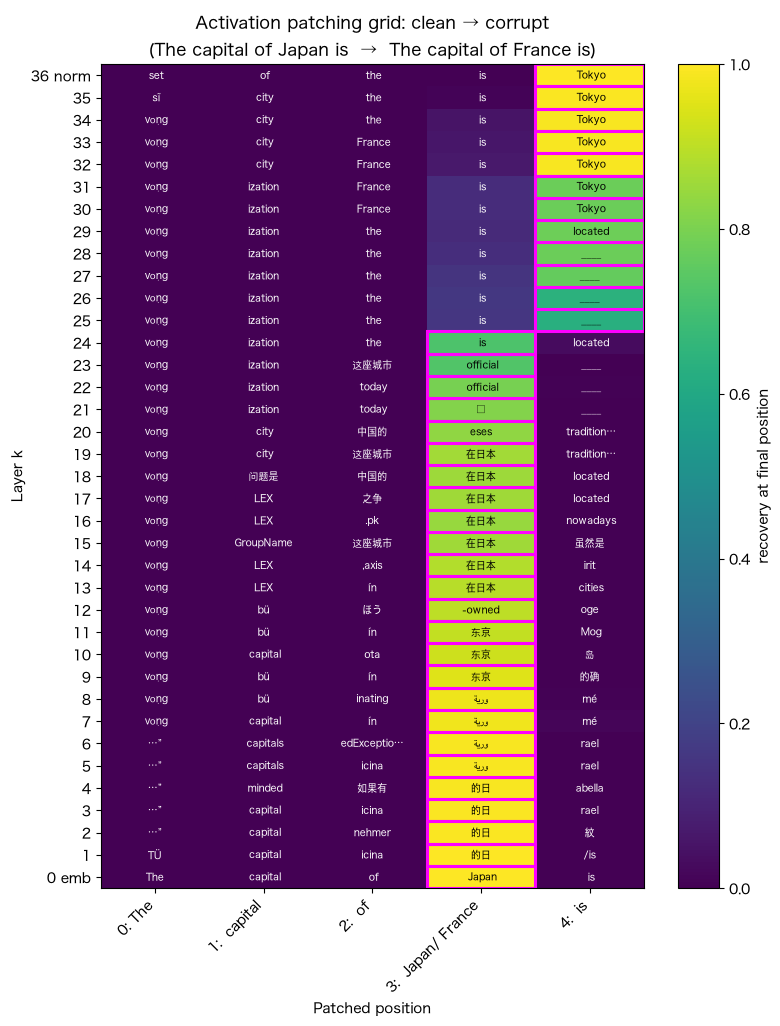

Saved: nb02_activation_patching_grid_recovery.png


In [52]:
# activation patching grid を heatmap として描画する。
#   色  : recovery_grid（recovery の値、viridis colormap）
#   文字: text_grid（clean activation の logit lens top-1 token）
#   枠  : patched_top1_is_clean（patch 後の最終 top-1 が " Tokyo" のとき magenta）

# 図サイズは grid のサイズに合わせて自動調整（小さすぎるとセル文字が読めなくなる）
fig_w = max(8.0, 1.6 * T_grid)
fig_h = max(10.0, 0.28 * (K + 1))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# vmin=0, vmax=1 で固定（recovery の意味的なレンジ）。範囲外の値は飽和して描画される。
cmap = plt.get_cmap("viridis")
im = ax.imshow(recovery_grid, aspect="auto", vmin=0.0, vmax=1.0, cmap=cmap, origin="lower")
ax.set_title(f"Activation patching grid: clean → corrupt\n({CLEAN_PROMPT}  →  {CORRUPT_PROMPT})")
ax.set_xlabel("Patched position")
ax.set_ylabel("Layer k")

# 横軸ラベル：clean と corrupt の token が同じ position は単一表示、異なる position は "clean/corrupt" 併記。
# 今回の prompt pair なら position 3 だけが "Japan/France" のように両方表示になる。
def _patch_pos_label(pos: int) -> str:
    c = short_piece(input_ids_clean_grid[pos])
    r = short_piece(input_ids_corrupt_grid[pos])
    if c == r:
        return f"{pos}: {c}"
    return f"{pos}: {c}/{r}"

ax.set_xticks(range(T_grid))
ax.set_xticklabels([_patch_pos_label(t) for t in range(T_grid)], rotation=45, ha="right")

# 縦軸ラベル：k=0 を "0 emb"、k=K を "K norm" として強調する。それ以外は数字のみ。
ylabels = []
for k in range(K + 1):
    if k == 0:
        ylabels.append("0 emb")
    elif k == K:
        ylabels.append(f"{k} norm")
    else:
        ylabels.append(str(k))
ax.set_yticks(range(K + 1))
ax.set_yticklabels(ylabels)

# セル内文字（clean logit lens top-1） + magenta 枠（patch 後の最終 top-1 が clean answer）
# 文字色は背景輝度に合わせて自動切替（暗いセルは白文字、明るいセルは黒文字）。
# magenta は viridis の両端（暗紫 / 明黄）どちらに対しても目立ち、かつ
# Section 8 の赤枠（logit lens grid の top-1 match マーカー）と混同しないように選んだ色。
for k in range(K + 1):
    for pos in range(T_grid):
        rec_clipped = float(max(0.0, min(1.0, recovery_grid[k, pos])))
        rgba        = cmap(rec_clipped)
        lum         = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]  # 知覚輝度
        text_color  = "white" if lum < 0.5 else "black"
        ax.text(pos, k, text_grid[k][pos],
                ha="center", va="center", fontsize=7, color=text_color)
        if patched_top1_is_clean[k, pos]:
            ax.add_patch(Rectangle(
                (pos - 0.5, k - 0.5), 1, 1,
                fill=False, edgecolor="magenta", linewidth=2.2,
            ))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("recovery at final position")

fig.tight_layout()
png_out = outputs_dir / "nb02_activation_patching_grid_recovery.png"
fig.savefig(png_out, dpi=200)
plt.show()
print(f"Saved: {png_out.name}")


### 観察と解釈

凡例：

- **色**：recovery（最後の position における `logit(" Tokyo") - logit(" Paris")` ベース）
- **マゼンタ枠**：patch 後の最終 top-1 が `" Tokyo"` になったセル
- **セル内文字**：patch した clean activation を logit lens で読んだ top-1 token (logit lens gridと同じ)


最初の 3 position（`The capital of`）は clean と corrupt で入力が同じなので、どの layer で patch しても何も変わりません（recovery ≈ 0）。残りの 2 列が興味深い対比になっています。

- **t=3（` Japan` / ` France` の位置）**：`k = 0,...,24` で patch したときだけ recovery が大きい。それ以降に patch しても効きません。
- **t=4（最後の position）**：逆に `k = 25,...,36` で patch したときだけ recovery が大きい。それより前に patch しても変わりません。

これは「t=3 に書き込まれた ` Japan` の情報を、後続の attention が t=4 に運び込み、最終 token を決定する処理が k=25 付近で走る」という構造を示しています。t=3 では **k=24 までに正しい情報を書き込んでおかないと間に合わない**し、t=4 では **k=25 以降にその情報が到達しないと書き換えが起こらない**わけです。

つまり、この境界となる **k=25 が、最終 token を ` Tokyo` 側に戻す本質的な処理が走る layer** であることが、grid の 2 列の対比から再確認できます。既存の recovery curve はこの grid の最後の列（t=4）を layer 方向に切り出したものに対応しており、k=25 付近の立ち上がりはまさにこの「t=4 で初めて情報が必要になる」現象を見ていることになります。


## 16. まとめ

### 観察結果

| 手法 | 観察したこと | Section |
|------|-------------|---------|
| **Logit Lens（最後の position）** | clean run（` Tokyo` 期待）では後半層（k≈25 以降）から ` Tokyo` が、corrupt run（` Paris` 期待）では同じく後半層から ` Paris` が、それぞれ top 候補として立ち上がる | Section 8（clean）, Section 9（corrupt） |
| **Logit Lens Grid（layer × position）** | 全 position で見ると、後半層では各 position で次 token に近い予測に収束する。中間層では `东京` / `这座城市` / `所在地` など中国語 token が top-1 に現れる position もあり、latent language の現象が観察できる | Section 8（clean）, Section 9（corrupt） |
| **Activation Patching（最後の position のみ）** | clean → corrupt 方向の patching で、k≤24 では recovery≈0、k=25 付近から急増、k≥34 では recovery≈1.0 | Section 13 |
| **Activation Patching Grid（layer × position）** | t=3（` Japan` 位置）は k=0〜24 で patch すると recovery が大きい。t=4（最後の position）は k=25〜36 で patch すると recovery が大きい。両者の窓が **k=25 を境に補完的に切り替わる** | Section 15 |

### 注意

- **一般化への注意**：上の観察を「知識が一般に後半層だけにある」と一般化してはいけない。あくまで **この prompt pair・この patching setup における観察**である。
- **Logit Lens と Activation Patching の差**：Logit Lens では ` Tokyo` の確率が明確に上がるのは k≈29 以降だが、Activation Patching では k=25 でも大きな recovery が得られた。これは両手法が**異なる操作**であることを反映している（詳細は Section 11 / Section 13 補足を参照）。


### 参考文献・参考資料

#### Transformer の基本

- <a id="ref-vaswani-2017">Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017).</a> *Attention Is All You Need*. Advances in Neural Information Processing Systems 30 (NeurIPS 2017).  
  URL: https://papers.nips.cc/paper/7181-attention-is-all-you-need  
  arXiv: https://arxiv.org/abs/1706.03762  
  Transformer architecture の基本論文。self-attention, feed-forward network, residual connection, layer normalization など、本ノートで扱う residual stream や後続 notebook で扱う Attention / FFN の背景となる。

- <a id="ref-alammar-2018">Alammar, J. (2018).</a> *The Illustrated Transformer*.  
  URL: https://jalammar.github.io/illustrated-transformer/  
  Transformer の図解解説。原論文より直感的に読みやすく、embedding, self-attention, feed-forward network, encoder/decoder などの流れを図で確認するための補助資料として有用。

- <a id="ref-qwen-2025">Qwen Team. (2025).</a> *Qwen3-4B*. Hugging Face model repository.  
  Model: https://huggingface.co/Qwen/Qwen3-4B  
  Technical report: Yang, A., et al. (2025). *Qwen3 Technical Report*. arXiv:2505.09388. https://arxiv.org/abs/2505.09388  
  本ノートで実際に用いる Qwen3-4B のモデル本体。Qwen3 系列の dense な 4B パラメータ級 causal language model であり、Hugging Face Transformers から読み込んで hidden states, attentions, logits などを取得できる。本ノートでは、このモデルに対して logit lens を適用し、各層の residual stream がどのような token 予測を与えるかを観察する。Transformer の基本構造が、実際の大規模言語モデルの内部表現としてどのように現れるかを確認するための具体例として用いる。

#### Logit lens と latent language

- <a id="ref-nostalgebraist-2020">nostalgebraist. (2020).</a> *interpreting GPT: the logit lens*. LessWrong, August 31, 2020.  
  URL: https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens  
  中間層の hidden state に最終層と同じ読み出しを適用し、「その時点でのモデルの暫定的な次 token 予測」として読む logit lens の元アイデア。本ノートの logit lens の説明と実験に直接関係する。後続研究では、この手法を用いて、多言語モデルの中間層がどの言語の token に近いかを調べることで、モデル内部の latent language（潜在言語）を可視化している。ただし、logit lens は中間表現を語彙空間に射影して読む近似的な可視化であり、「モデルがその語を意識的に考えている」と断定するものではない。

- <a id="ref-wendler-2024">Wendler, C., Veselovsky, V., Monea, G., & West, R. (2024).</a> *Do Llamas Work in English? On the Latent Language of Multilingual Transformers*. Proceedings of the 62nd Annual Meeting of the Association for Computational Linguistics (ACL 2024), Long Papers.  
  URL: https://aclanthology.org/2024.acl-long.820/  
  arXiv: https://arxiv.org/abs/2402.10588  
  Code: https://github.com/epfl-dlab/llm-latent-language  
  Llama-2 系モデルを対象に、非英語入力・非英語出力の途中で中間層が英語 token に近づくかを logit lens で調べた研究。Figure 1 では、フランス語から中国語への翻訳プロンプトに対して、最終層では中国語の正解 token が出る一方、中間層では英語の “flower” が現れる例が示されている。著者らは、単純に「英語へ翻訳してから考える」と断定するのではなく、中間層の概念空間が英語語彙空間に近い、という形で解釈している。本ノートで扱う Qwen3-4B の logit lens grid と対比することで、英語中心モデルでは英語に寄り、中国語中心モデルでは中国語に寄る可能性があることを説明するための重要な参考文献。

- <a id="ref-zhong-2025">Zhong, C., Liu, Q., Cheng, F., Jiang, J., Wan, Z., Chu, C., Murawaki, Y., & Kurohashi, S. (2025).</a> *What Language Do Non-English-Centric Large Language Models Think in?* Findings of the Association for Computational Linguistics: ACL 2025.  
  URL: https://aclanthology.org/2025.findings-acl.1350/  
  arXiv: https://arxiv.org/abs/2408.10811  
  Code: https://github.com/ku-nlp/latent_language_of_multilingual_model  
  非英語中心の大規模言語モデルが、内部でどの言語を latent language として使うかを logit lens で調べた研究。主な対象は日本語処理モデル（Swallow のように日本語で継続事前学習したモデルや、英語と日本語をバランスよく含むデータで事前学習したモデル）で、英語中心モデルでは中間層が主に英語に寄る一方、これらのモデルでは日本語などの latent language が中間層に現れることを示している（フランス語・中国語などは比較・対象言語として用いられる）。翻訳タスクでは、入力言語に近い latent language から出力言語に近い latent language へ確率質量が段階的に移る “Probabilistic Cascade” も報告されている。本ノートの Qwen3-4B で中国語 token が中間層に現れる観察については、latent language 一般の背景文献として参照するが、Zhong et al. が Qwen3 の中国語 latent を直接示した文献ではない点に注意。

- <a id="ref-schut-2025">Schut, L., Gal, Y., & Farquhar, S. (2025).</a> *Do Multilingual LLMs Think In English?* arXiv:2502.15603.  
  URL: https://arxiv.org/abs/2502.15603  
  Llama-3.1, Gemma, Mixtral, Aya などを対象に、多言語 LLM が open-ended generation の途中で英語に近い表現を使うかを調べた研究。logit lens による解析では、名詞や動詞など意味内容を担う lexical words は英語 token として中間層に現れやすい一方、冠詞・前置詞・接続詞などの機能語は必ずしも英語経由にならないことを示している。また、activation steering では、非英語出力を誘導する場合でも英語から作った steering vector が有効であることを示し、意味的判断が英語寄りの表現空間で行われる可能性を補強している。Wendler et al. (2024) を open-ended generation と intervention の観点から拡張する文献として、本ノートの logit lens 解釈の補助資料になる。


#### Activation patching と内部表現への介入

- <a id="ref-meng-2022">Meng, K., Bau, D., Andonian, A., & Belinkov, Y. (2022).</a> *Locating and Editing Factual Associations in GPT*. Advances in Neural Information Processing Systems 35 (NeurIPS 2022).  
  arXiv: https://arxiv.org/abs/2202.05262  
  Project page: https://rome.baulab.info/  
  GPT 内部で factual prediction に関わる activations を causal intervention により調べ、ROME (Rank-One Model Editing) による model editing へ接続した研究。本ノートの residual stream patching は、この論文で用いられる Causal Tracing と同様に、clean/corrupt run の activation を差し替えて最終出力への影響を見る簡略化されたデモである。

- <a id="ref-heimersheim-2024">Heimersheim, S., & Nanda, N. (2024).</a> *How to use and interpret activation patching*. arXiv:2404.15255.  
  URL: https://arxiv.org/abs/2404.15255  
  LessWrong version: https://www.lesswrong.com/posts/FhryNAFknqKAdDcYy/how-to-use-and-interpret-activation-patching  
  Activation patching の使い方と解釈上の注意を整理したチュートリアル。本ノートのような residual stream patching をどう解釈すべきか、metric の選び方や clean→corrupt / corrupt→clean の違いを考える際の補足資料。

- <a id="ref-nanda-2022">Nanda, N., & Bloom, J. (2022).</a> *TransformerLens*. Software library.  
  URL: https://github.com/TransformerLensOrg/TransformerLens  
  Documentation: https://transformerlensorg.github.io/TransformerLens/  
  Citation: https://transformerlensorg.github.io/TransformerLens/content/citation.html  
  Transformer の内部 activations を取得・編集する mechanistic interpretability 用ライブラリ。logit lens や activation patching の実装・検証に広く使われる。本ノート本体では Hugging Face Transformers と自前 hook を使うが、事前調査スクリプトでは自前 logit lens 実装と TransformerLens 実装の一致を確認した。